# Agentic EDA — Step-by-Step Interactive Workflow Notebook

This notebook walks through the **Agentic Exploratory Data Analysis (EDA)** pipeline step-by-step.

Instead of running the automated pipeline script as a single black box, this notebook breaks down each agent's execution, showing:
- **Grounding Profile**: What data the agent sees before making decisions.
- **Reasoning Steps**: The structured chain-of-thought produced by each LLM stage.
- **Generated Python/Matplotlib Code**: The pandas data prep and matplotlib visualization code emitted by the models.
- **Visual Outputs**: The cleaned dataset, individual charts, and the final multimodal synthesized markdown report.

## Step 0: Setup and Environment Configuration

Import configuration, helper functions, and agent modules from the `agentic_eda` package.

In [1]:
import sys
import os
from pathlib import Path
from IPython.display import display, Markdown, Image

# Ensure project root is in sys.path regardless of where Jupyter is launched
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "agentic_eda" else cwd
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import configuration and utilities
from agentic_eda.config import (
    DATA_DIR,
    CLEANED_DATA_DIR,
    UNIVARIATE_CHARTS_DIR,
    MULTIVARIATE_CHARTS_DIR,
    REPORTS_DIR,
    OPENAI_API_KEY,
)
from agentic_eda.utils import profile_dataset, correlation_profile

# Import agent entry points
from agentic_eda.data_prep.agent import run_data_prep
from agentic_eda.univariate_analysis.agent import run_univariate_analysis
from agentic_eda.multivariate_analysis.agent import run_multivariate_analysis
from agentic_eda.report.agent import collect_context, run_report

print("Setup completed successfully.")
print(f"Data Directory: {DATA_DIR}")
print(f"OpenAI API Key configured: {bool(OPENAI_API_KEY)}")

Setup completed successfully.
Data Directory: C:\Users\Sreeharsha\github-dev\agentic-ai\agentic_eda\data
OpenAI API Key configured: True


## Step 1: Raw Data Grounding & Initial Profiling

Inspect the raw dataset before passing it to the Data Preparation Agent. `profile_dataset` computes schema metadata, null counts, data types, and head previews.

In [2]:
raw_csv_path = DATA_DIR / "sales_data.csv"

if not raw_csv_path.exists():
    raise FileNotFoundError(f"Dataset not found at {raw_csv_path}. Please download it from Kaggle and place it in agentic_eda/data/.")

print("--- Raw Dataset Profile Preview ---")
raw_profile = profile_dataset(raw_csv_path)
print(raw_profile[:1000] + "\n...\n(truncated for preview)")

--- Raw Dataset Profile Preview ---
File: sales_data.csv
Shape: 185950 rows x 11 columns

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185950 non-null  int64  
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  str    
 3   Quantity Ordered  185950 non-null  int64  
 4   Price Each        185950 non-null  float64
 5   Order Date        185950 non-null  str    
 6   Purchase Address  185950 non-null  str    
 7   Month             185950 non-null  int64  
 8   Sales             185950 non-null  float64
 9   City              185950 non-null  str    
 10  Hour              185950 non-null  int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 15.6 MB


--- Null counts per column ---
Unnamed: 0          0
Order ID            0
Product             0
Quantity O

## Step 2: Agent 1 — Data Preparation Agent

The **Data Prep Agent** inspects the raw CSV profile, reasons step-by-step about null handling, date normalizations (forcing derived `Year`, `Month`, `Day`, `Hour` columns), and column filtering, and generates an executable pandas cleaning script run in a child subprocess.

In [3]:
print("Running Data Prep Agent...")
prep_result, cleaned_csv_path = run_data_prep(raw_csv_path)

print("\n=== DATA PREP SUMMARY ===")
print(prep_result.summary)

print("\n=== AGENT REASONING STEPS ===")
for step in prep_result.reasoning_steps:
    print(f"[{step.phase.upper()}]")
    print(f"  Observation: {step.observation}")
    print(f"  Action:      {step.action}\n")

print("=== GENERATED CLEANING CODE ===")
print(prep_result.code)

print(f"\nCleaned CSV written to: {cleaned_csv_path}")

Running Data Prep Agent...
File: sales_data.csv
Shape: 185950 rows x 11 columns

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185950 non-null  int64  
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  str    
 3   Quantity Ordered  185950 non-null  int64  
 4   Price Each        185950 non-null  float64
 5   Order Date        185950 non-null  str    
 6   Purchase Address  185950 non-null  str    
 7   Month             185950 non-null  int64  
 8   Sales             185950 non-null  float64
 9   City              185950 non-null  str    
 10  Hour              185950 non-null  int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 15.6 MB


--- Null counts per column ---
Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered   

## Step 3: Agent 2a — Univariate Analysis Agent

The **Univariate Analysis Agent** uses a **multi-turn conversation**:
- **Turn 1 (Planning)**: Classifies variables and plans appropriate single-variable charts (histograms, bar plots, top-N).
- **Turn 2 (Code Generation)**: Writes a single matplotlib script to render all selected charts.
- **Subprocess Execution & Self-Correction**: Executes the code in a headless subprocess, auto-correcting any errors.

In [4]:
print("Running Univariate Analysis Agent...")
univariate_result, univariate_charts = run_univariate_analysis(cleaned_csv_path)

print("\n=== UNIVARIATE ANALYSIS SUMMARY ===")
print(univariate_result.summary)

print("\n=== VARIABLE SELECTION PLANS ===")
for plan in univariate_result.variable_plans:
    mark = "[x]" if plan.selected else "[ ]"
    print(f"  {mark} {plan.variable:<20} ({plan.data_kind}) -> Chart: {plan.chart_type}")
    print(f"      Rationale: {plan.rationale}\n")

print(f"Generated {len(univariate_charts)} chart image(s):")
for path in univariate_charts:
    print(f"  - {path}")

Running Univariate Analysis Agent...

=== UNIVARIATE ANALYSIS SUMMARY ===
The script renders and saves nine isolated univariate charts for the selected categorical, discrete, date-part, and sales variables while skipping the two high-cardinality fields.

=== VARIABLE SELECTION PLANS ===
  [ ] Order ID             (identifier_skip) -> Chart: skipped
      Rationale: Very high cardinality (178,437 distinct values) and functions as a transaction identifier rather than a meaningful distributional variable.

  [x] Product              (categorical) -> Chart: horizontal bar counts
      Rationale: Manageable categorical field with 19 product categories; plot category frequencies, showing the most frequent products clearly.

  [x] Quantity Ordered     (numeric_discrete) -> Chart: bar counts
      Rationale: Has only 9 distinct integer values and represents discrete order quantities; show counts ordered by quantity.

  [x] Price Each           (numeric_discrete) -> Chart: bar counts
      Rati

### View Generated Univariate Charts


Chart: city.png


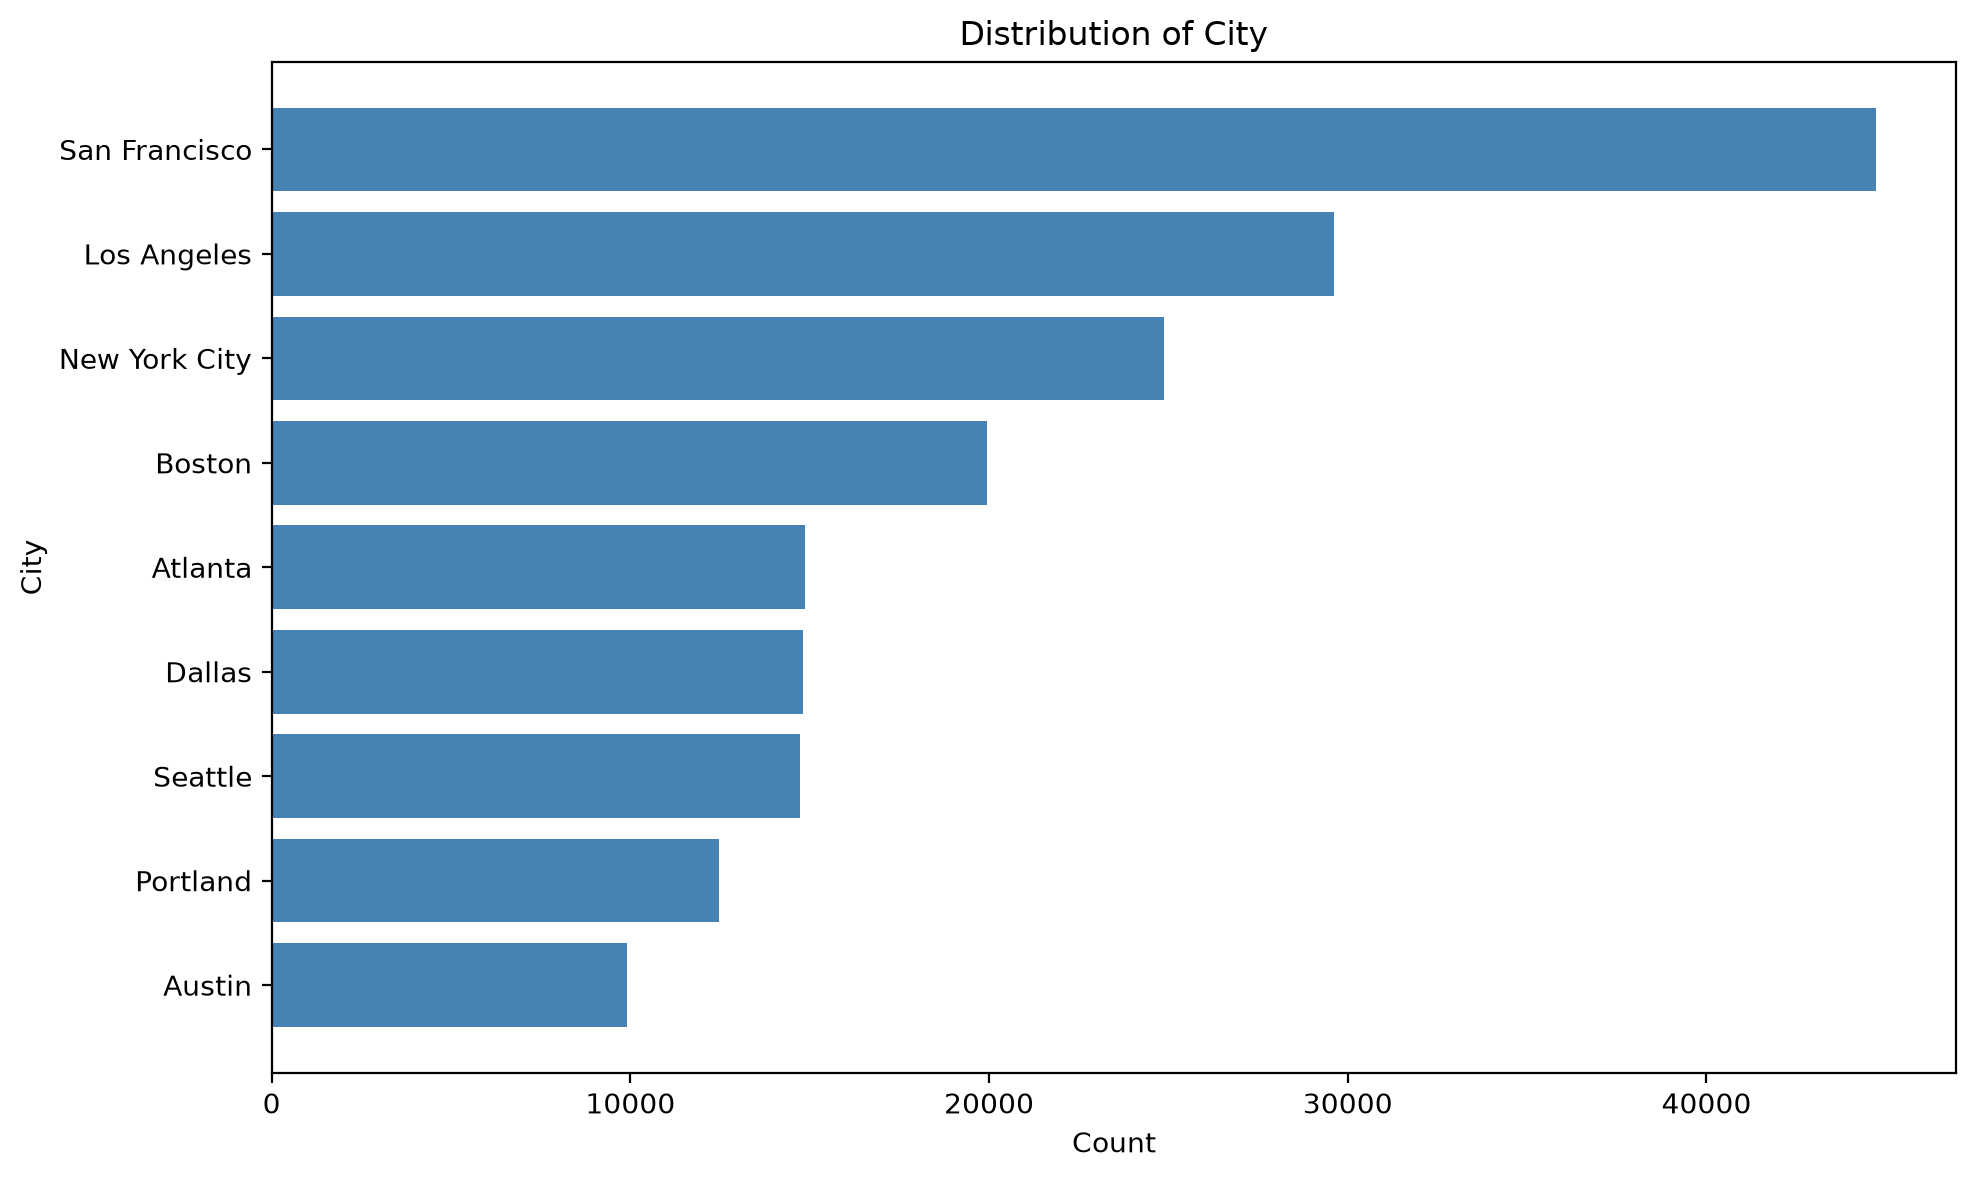


Chart: day.png


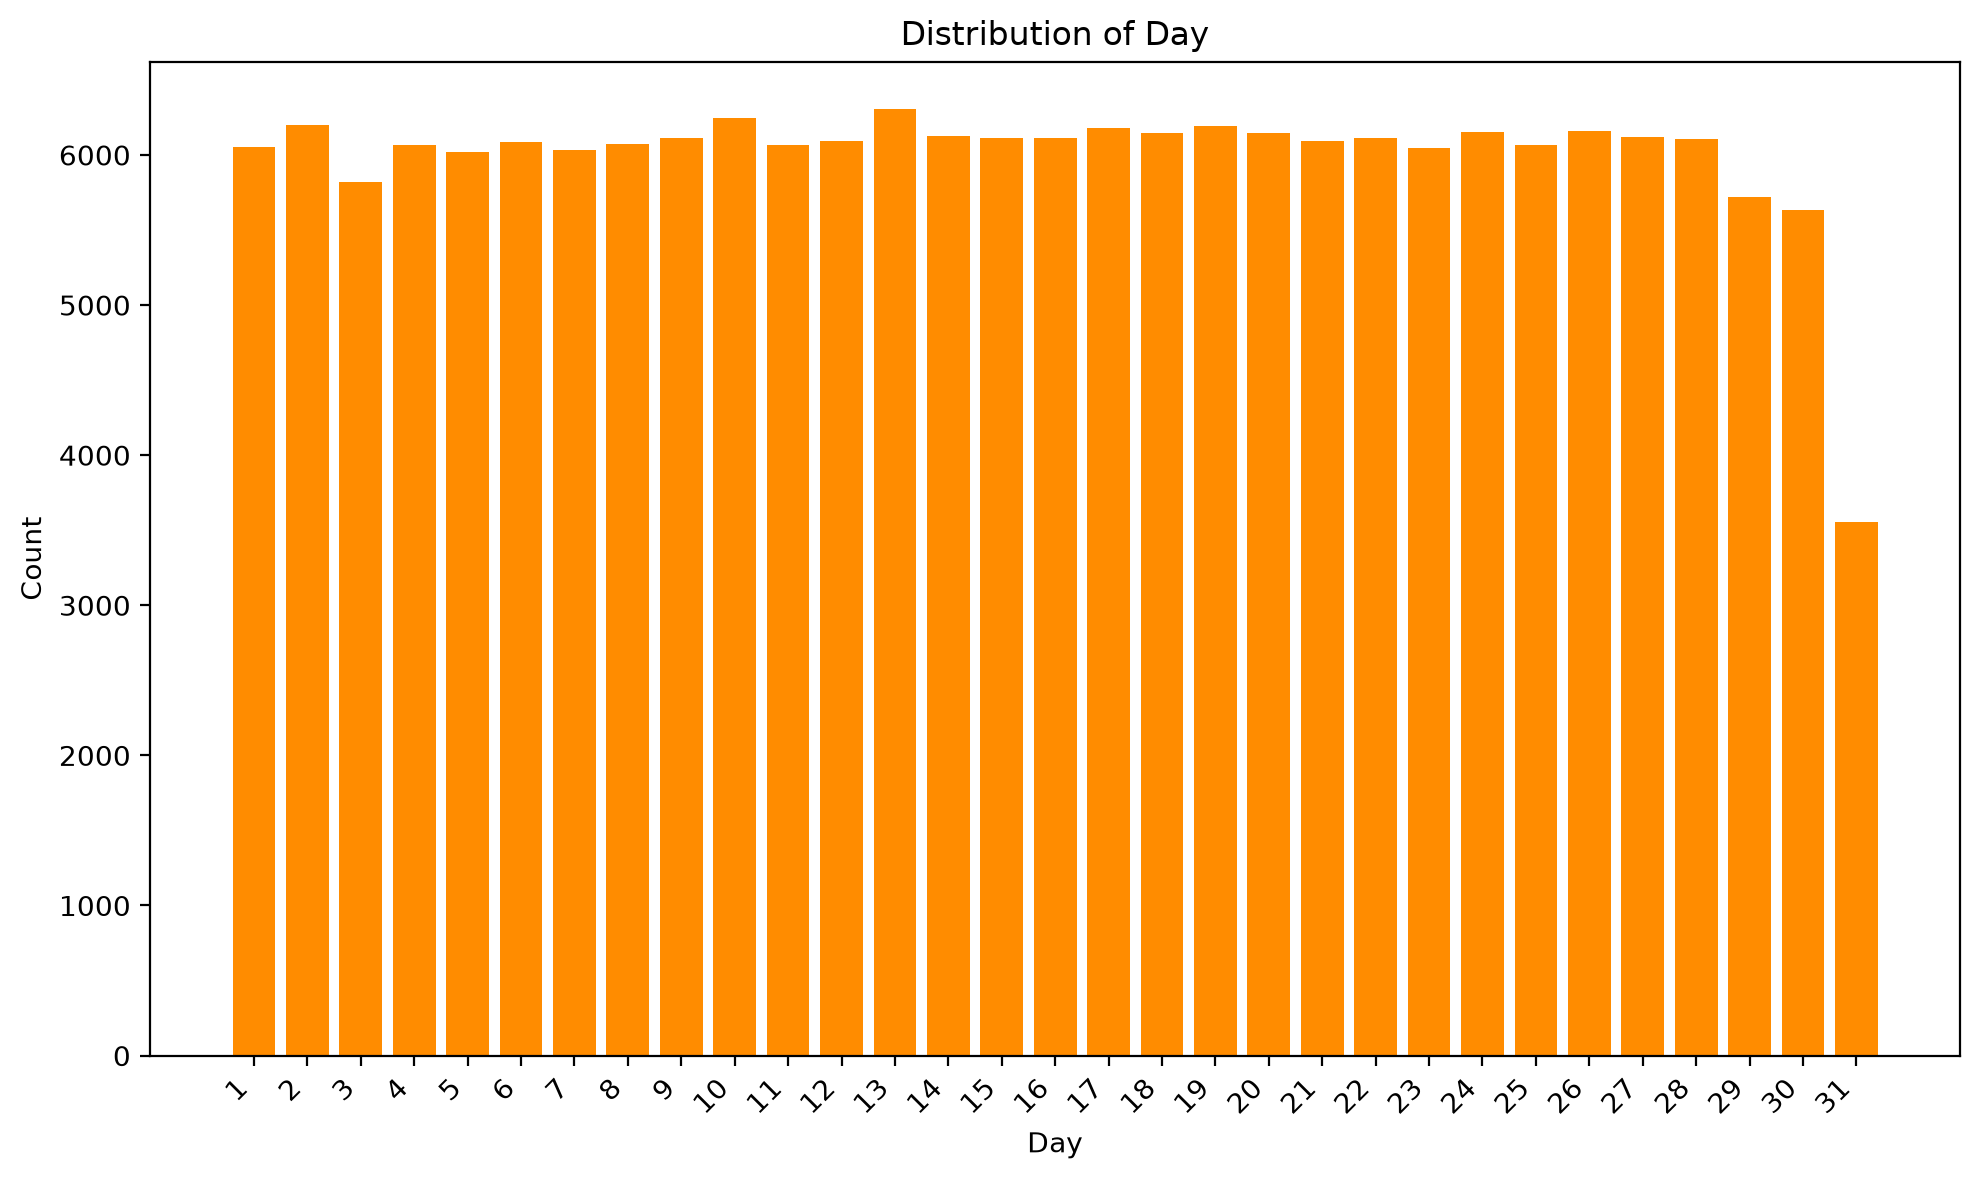


Chart: hour.png


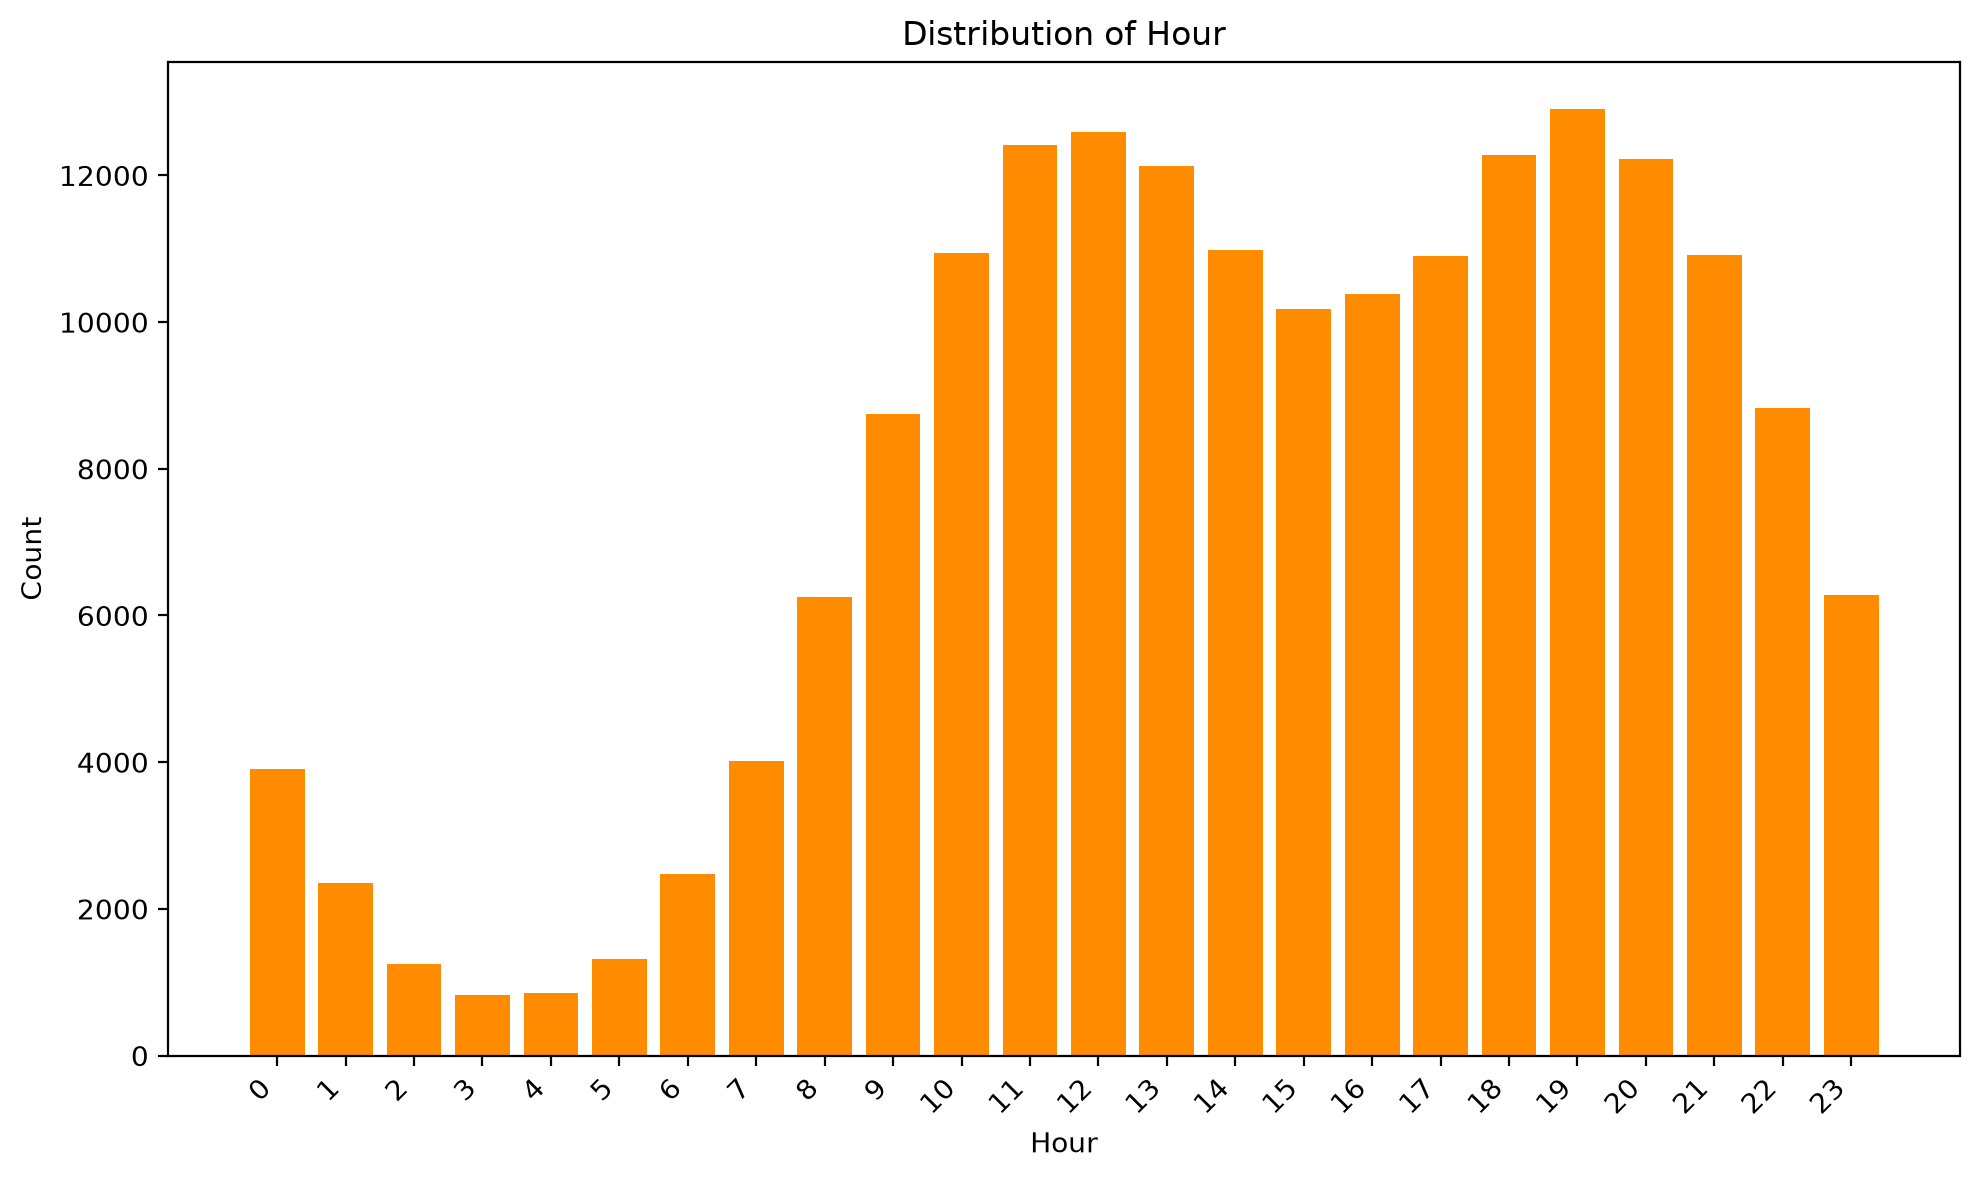


Chart: month.png


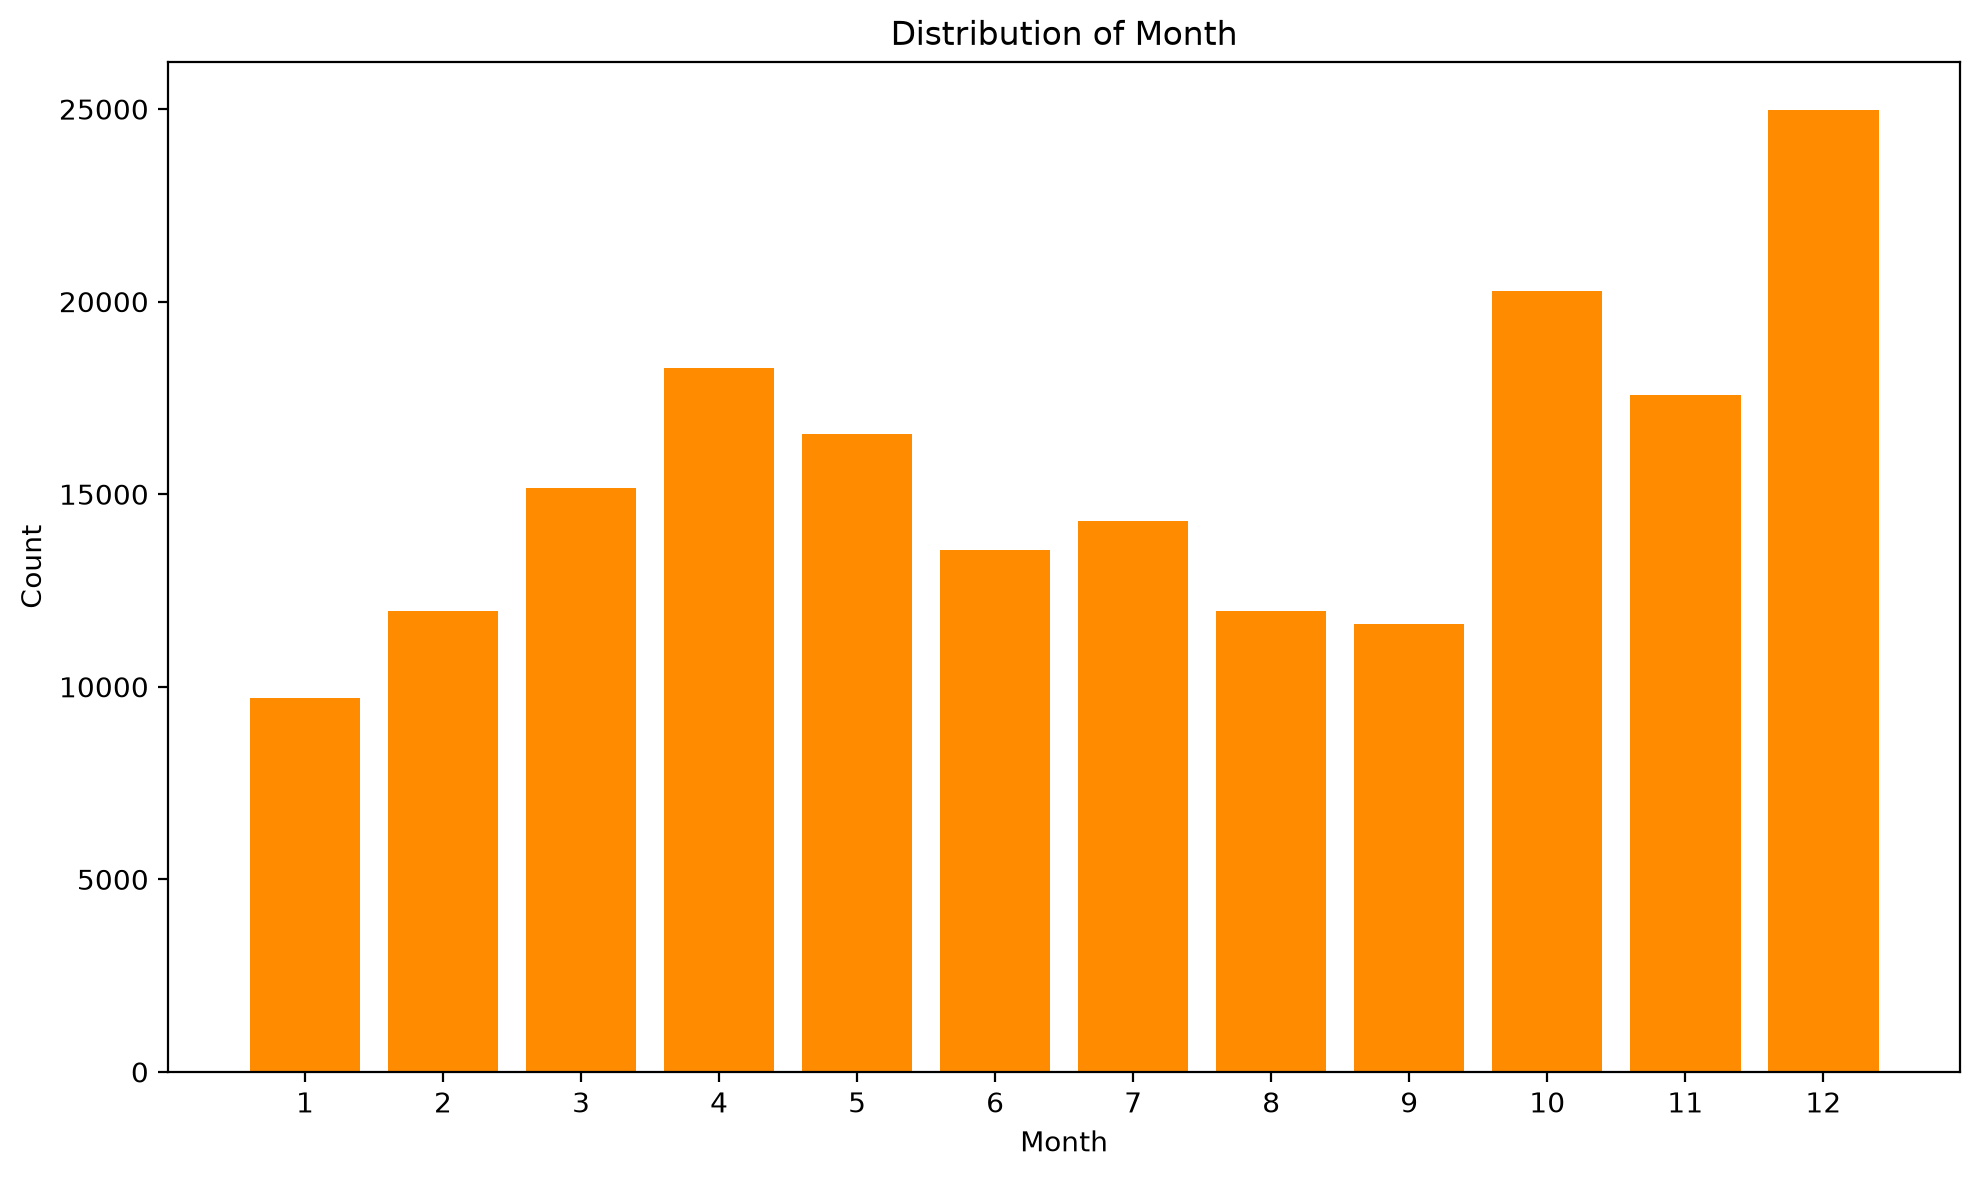


Chart: price_each.png


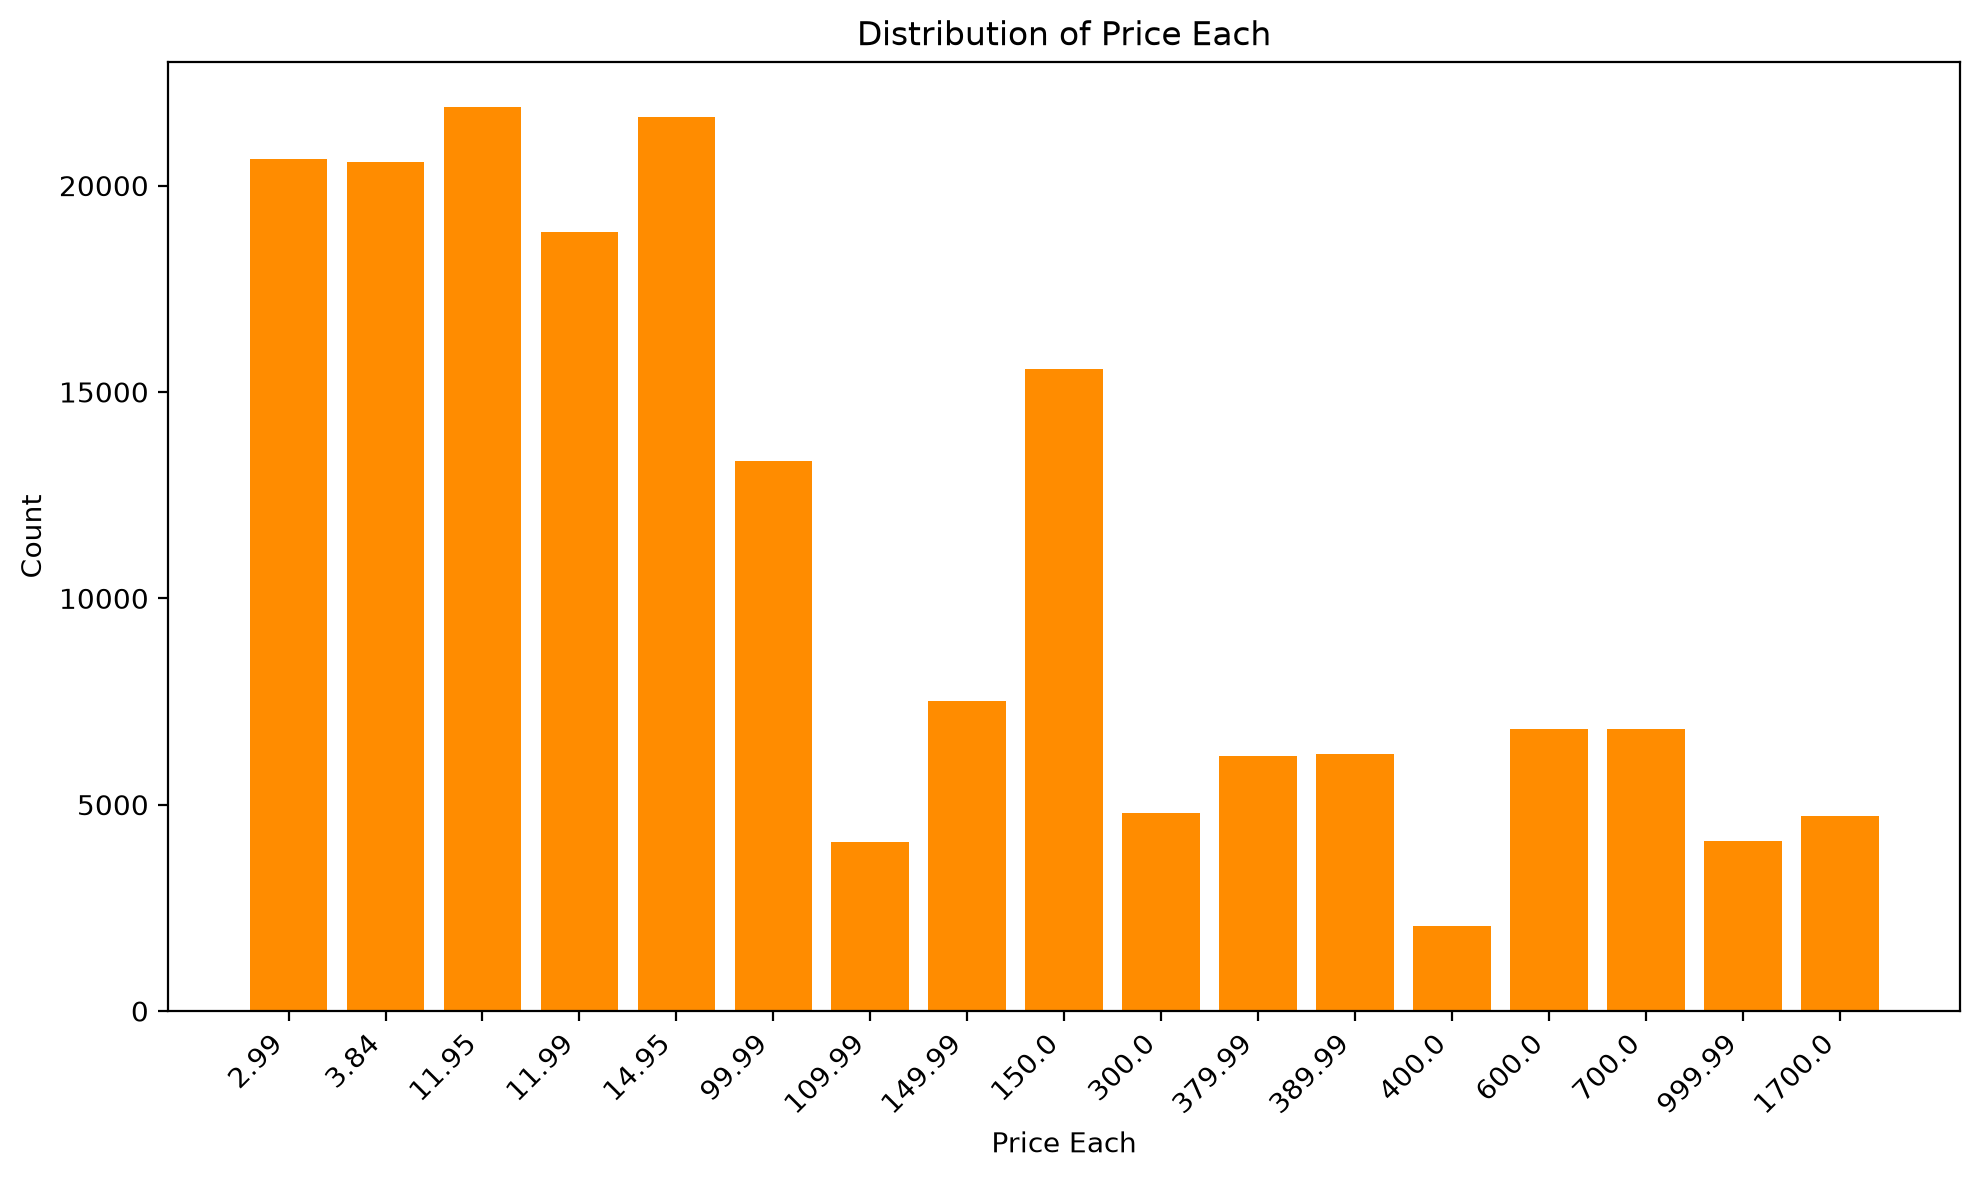


Chart: product.png


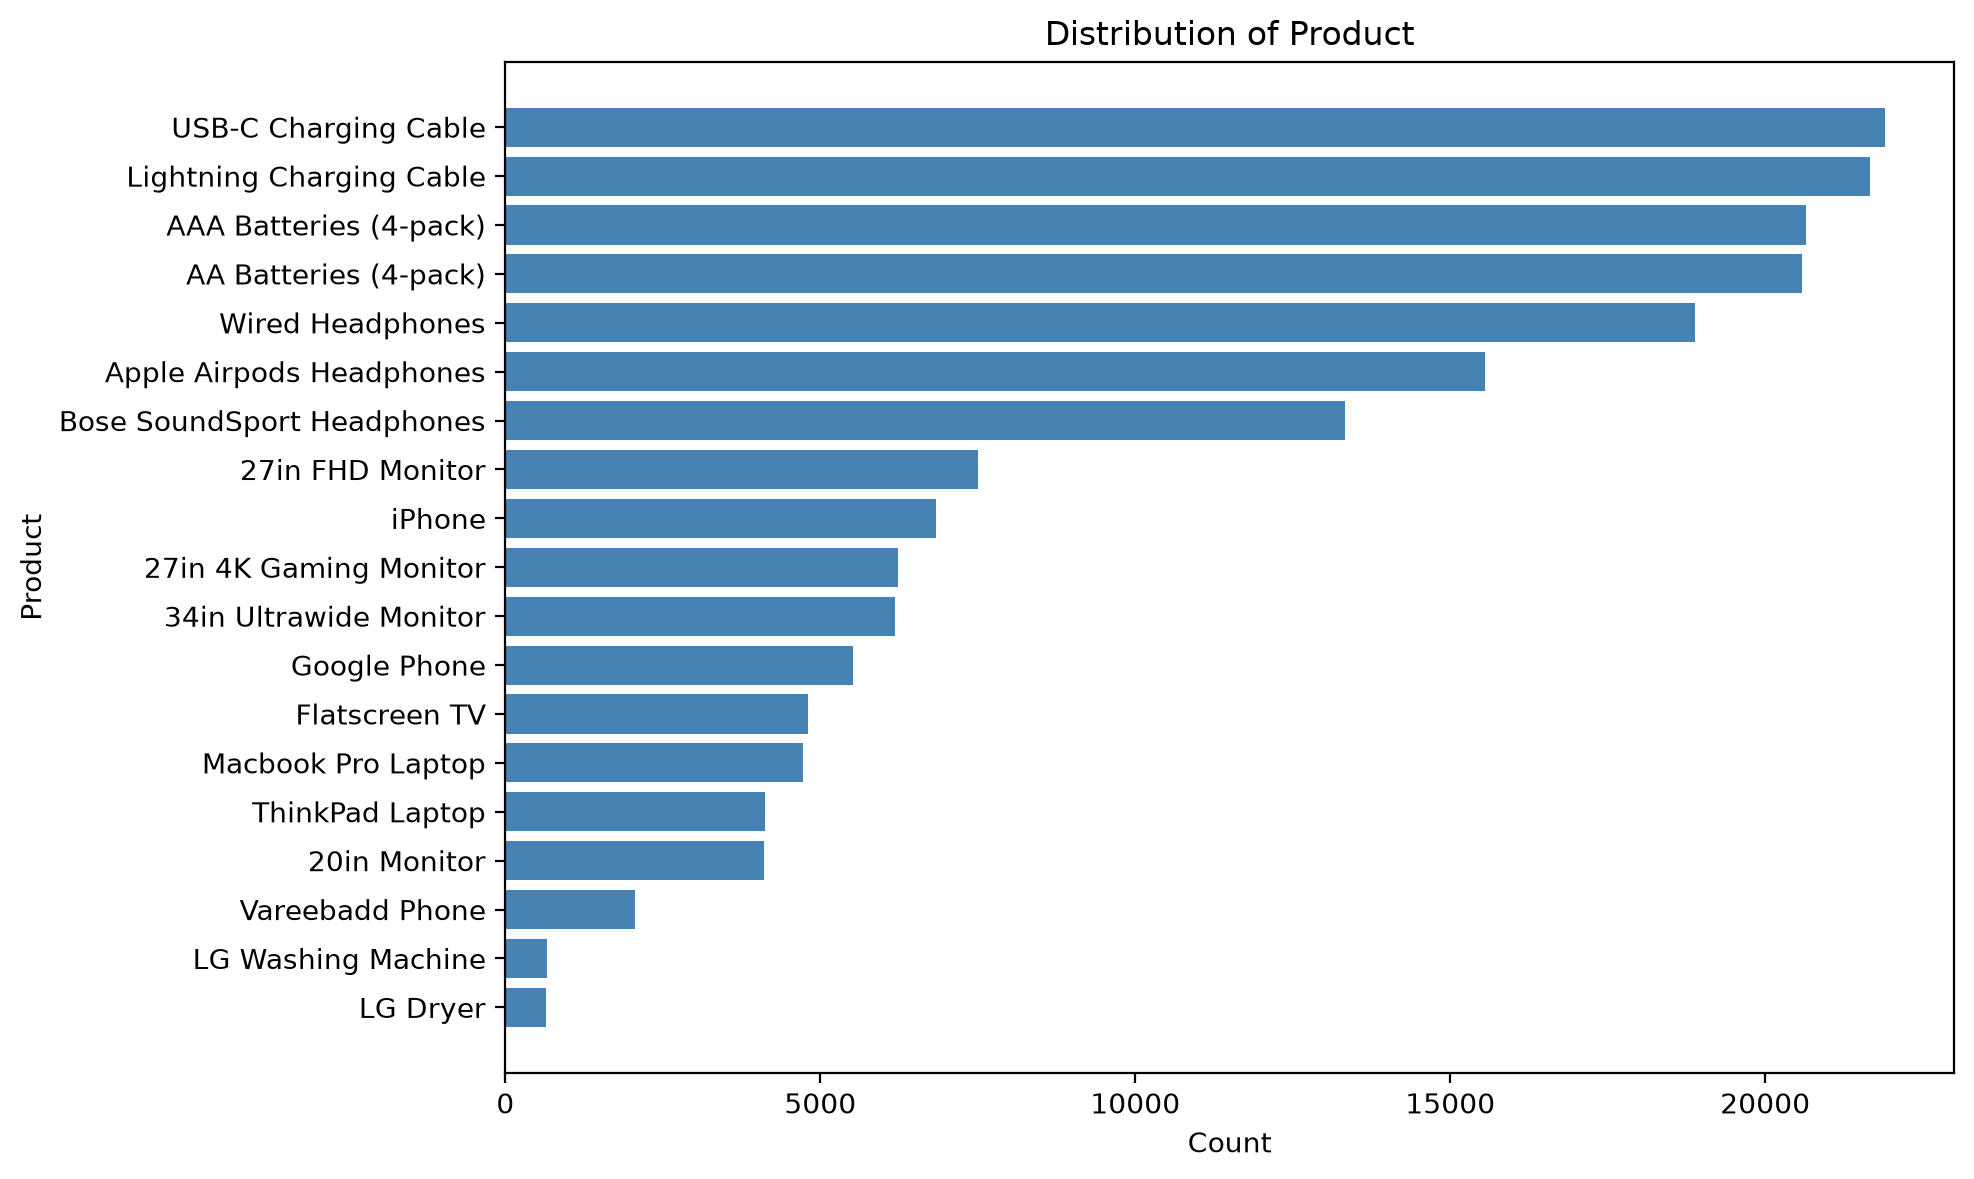


Chart: quantity_ordered.png


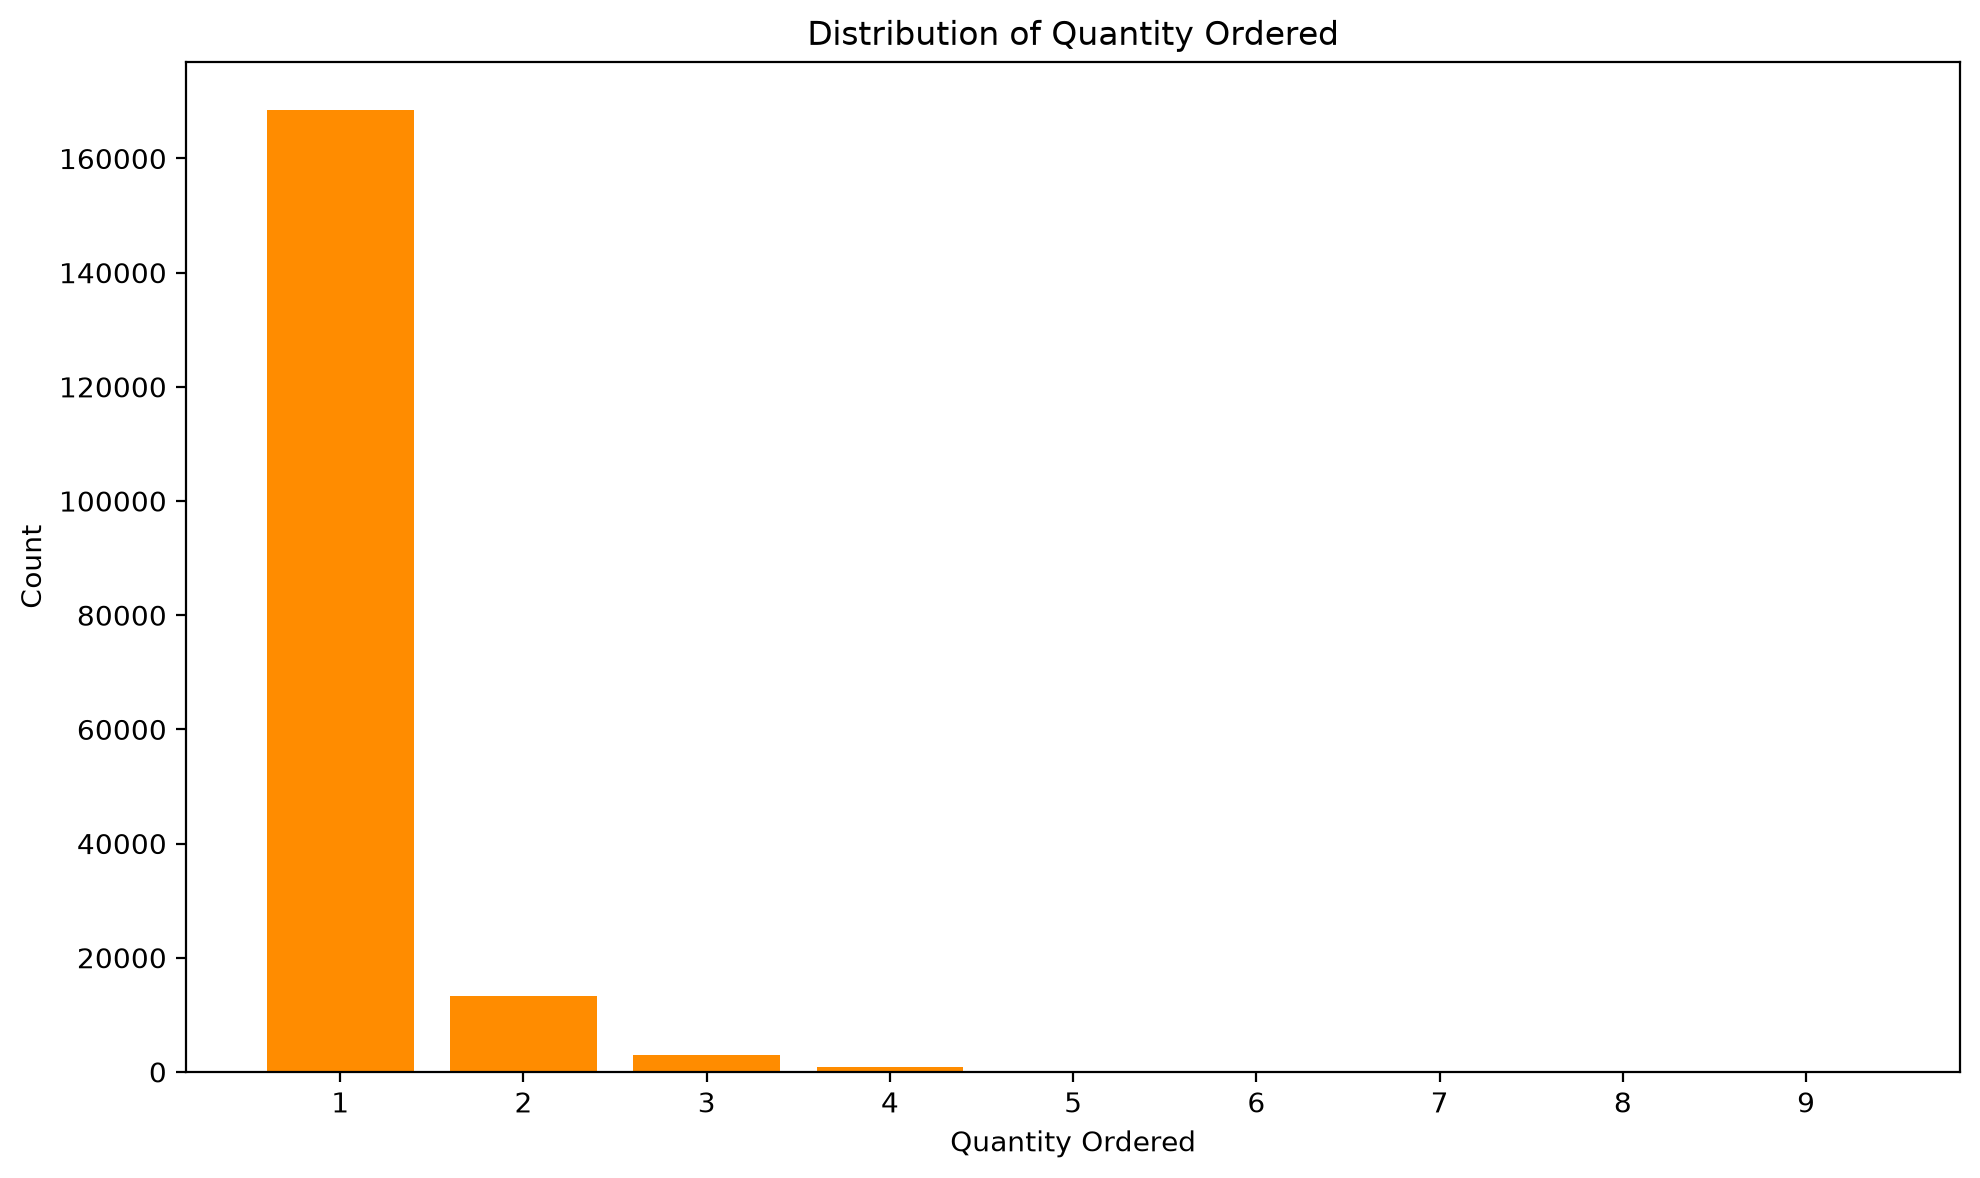


Chart: sales.png


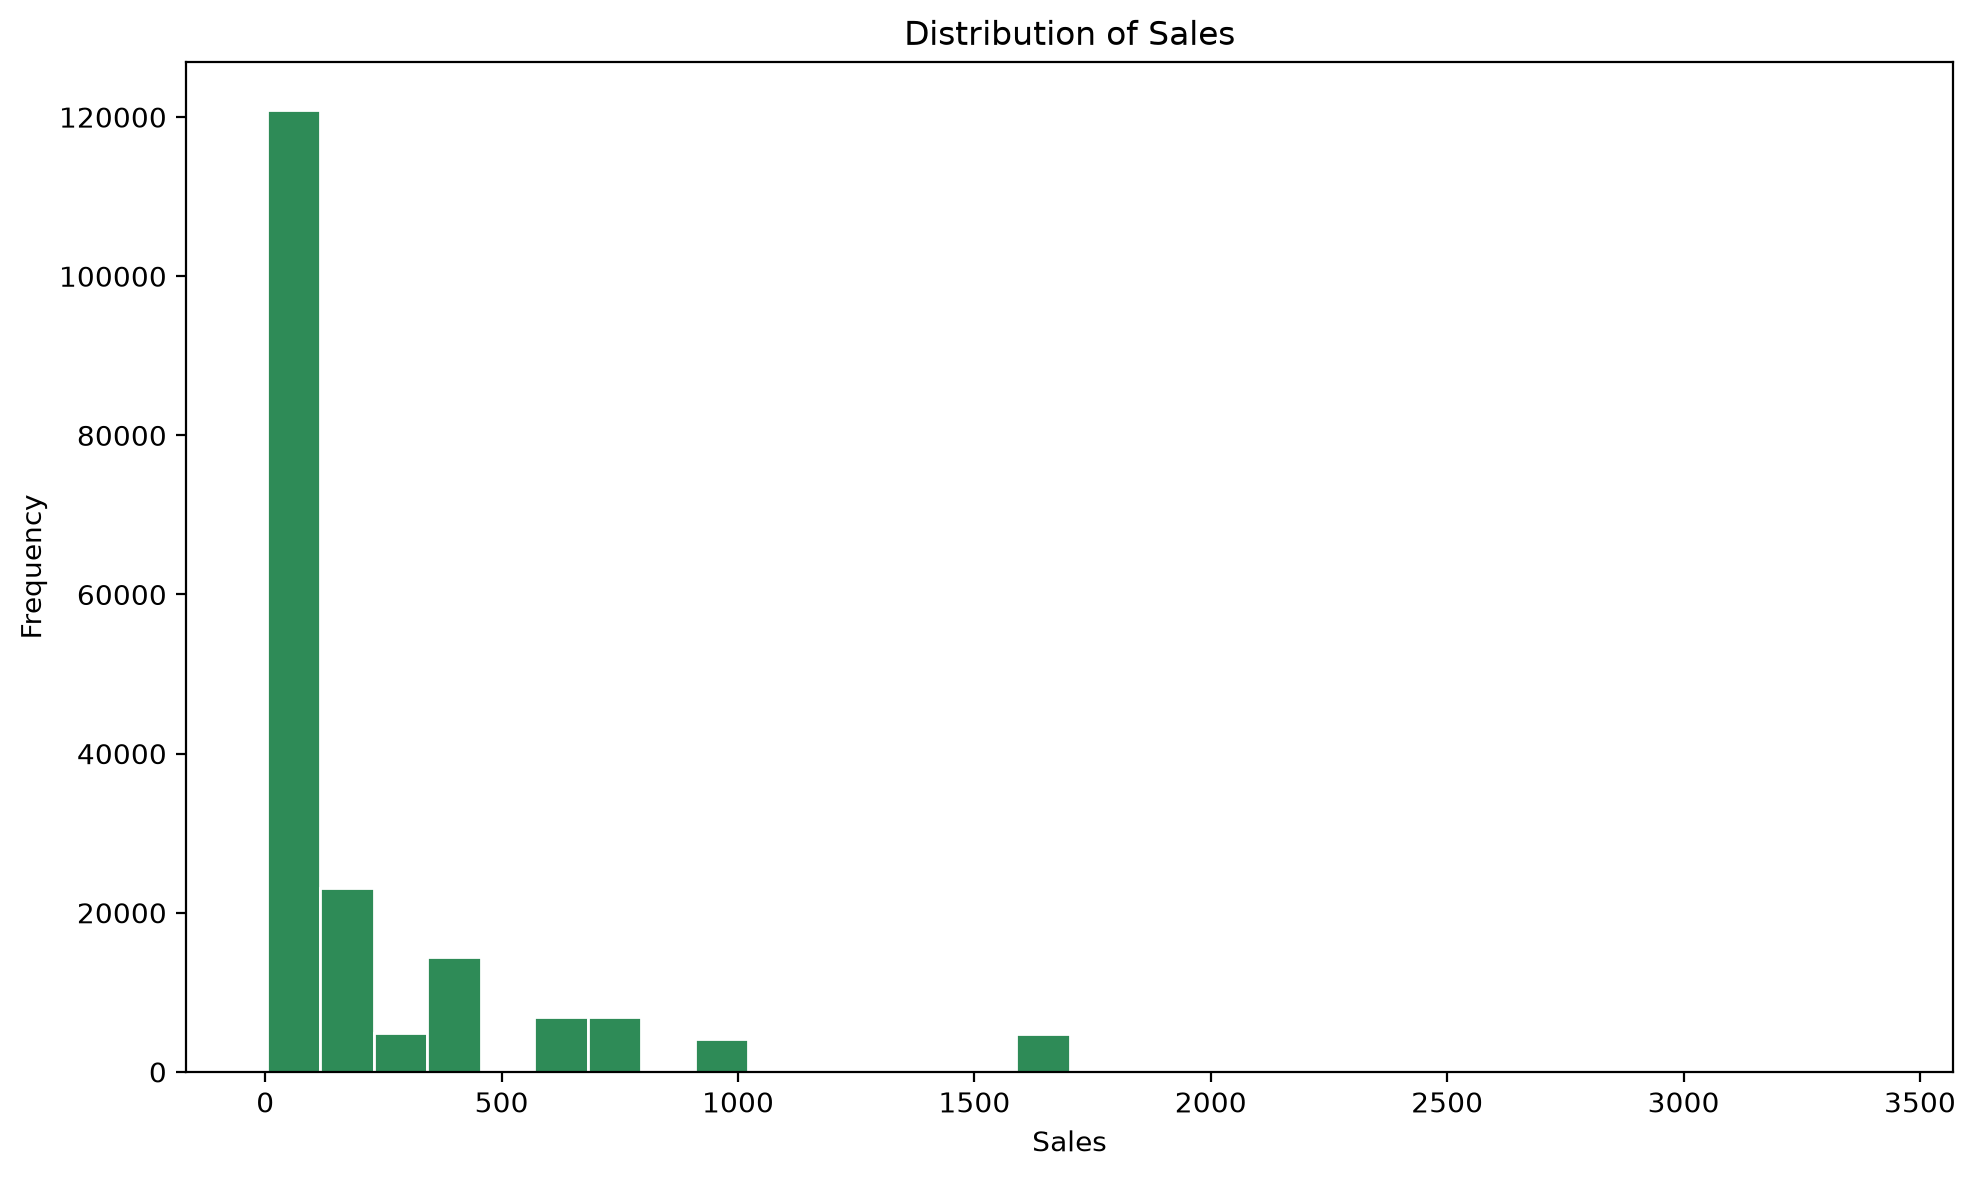


Chart: year.png


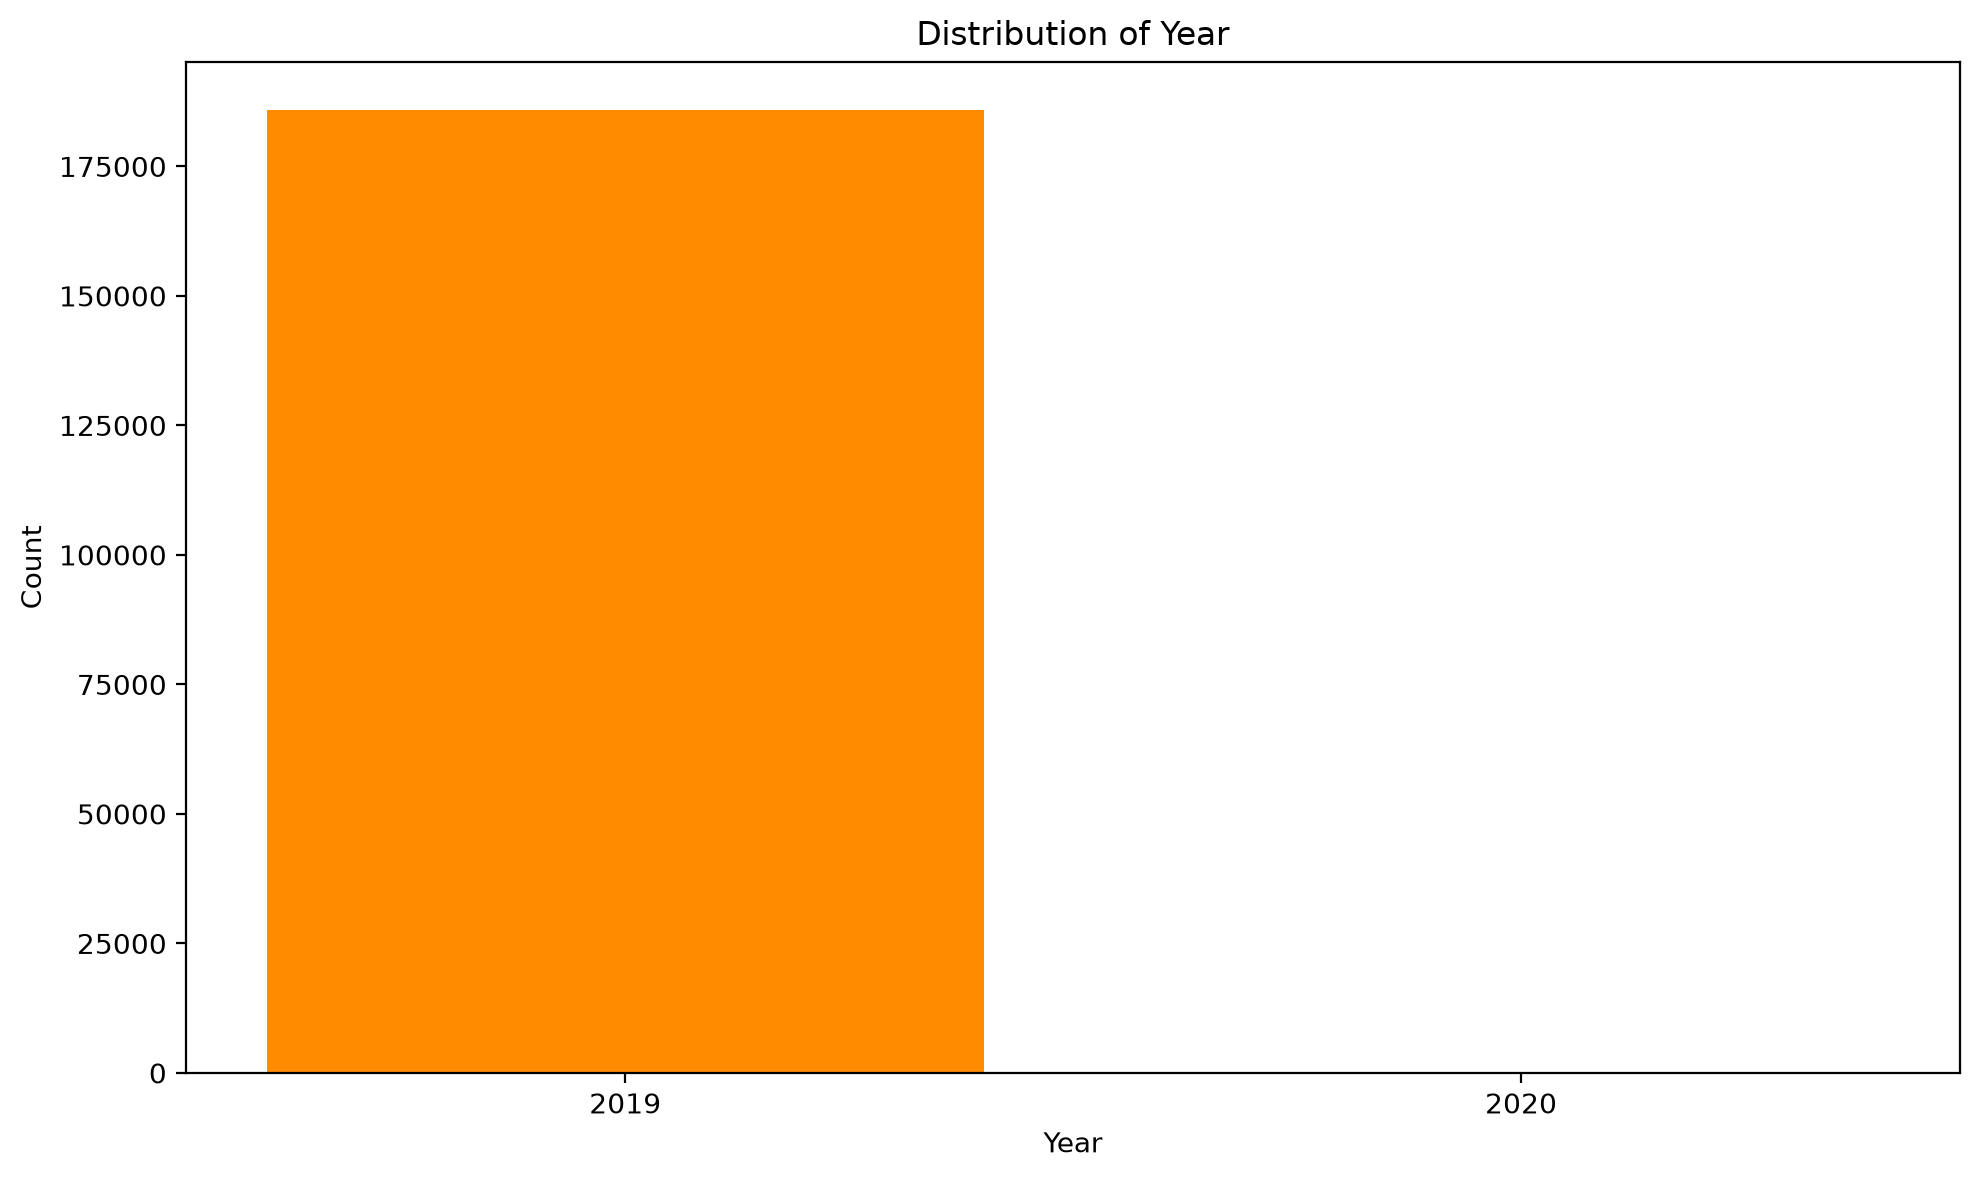

In [5]:
for chart_path in univariate_charts:
    print(f"\nChart: {chart_path.name}")
    display(Image(filename=str(chart_path)))

## Step 4: Agent 2b — Multivariate Analysis Agent

The **Multivariate Analysis Agent** also operates via a **multi-turn conversation**:
- Computes a deterministic correlation profile in Python.
- **Turn 1 (Selection)**: Identifies relationship pairs clearing a correlation threshold ($|r| \ge 0.3$) plus a correlation heatmap.
- **Turn 2 (Code Generation)**: Emits a matplotlib script for the selected pairs and correlation heatmap.

In [6]:
print("Running Multivariate Analysis Agent...")
multivariate_result, multivariate_charts = run_multivariate_analysis(cleaned_csv_path)

print("\n=== MULTIVARIATE ANALYSIS SUMMARY ===")
print(multivariate_result.summary)

print("\n=== RELATIONSHIP PLANS ===")
for plan in multivariate_result.relationship_plans:
    pair = f"{plan.variable_x} vs {plan.variable_y}" if plan.variable_y else plan.variable_x
    mark = "[x]" if plan.selected else "[ ]"
    corr = f"r={plan.correlation:+.3f}" if plan.correlation is not None else "r=n/a"
    print(f"  {mark} {pair:<30} ({corr}) -> Chart: {plan.chart_type}")
    print(f"      Rationale: {plan.rationale}\n")

print(f"Generated {len(multivariate_charts)} chart image(s):")
for path in multivariate_charts:
    print(f"  - {path}")

Running Multivariate Analysis Agent...

=== MULTIVARIATE ANALYSIS SUMMARY ===
The script renders the selected correlation, transaction-value, product, geography, calendar, and hourly-sales relationships as eight independently saved PNG figures.

=== RELATIONSHIP PLANS ===
  [x] All numeric columns            (r=n/a) -> Chart: correlation heatmap
      Rationale: Required overall view of correlations among all numeric columns, including detection of the strong Price Each-Sales relationship and the identifier-driven Order ID-Month artifact.

  [ ] Order ID vs Quantity Ordered   (r=+0.001) -> Chart: skipped
      Rationale: Order ID is a high-cardinality identifier and is not an appropriate analytic axis; the correlation is also negligible.

  [ ] Order ID vs Price Each         (r=-0.003) -> Chart: skipped
      Rationale: Order ID is an identifier, and the observed relationship is negligible.

  [ ] Order ID vs Sales              (r=-0.003) -> Chart: skipped
      Rationale: Order ID is 

### View Generated Multivariate Charts & Heatmap


Chart: correlation_heatmap.png


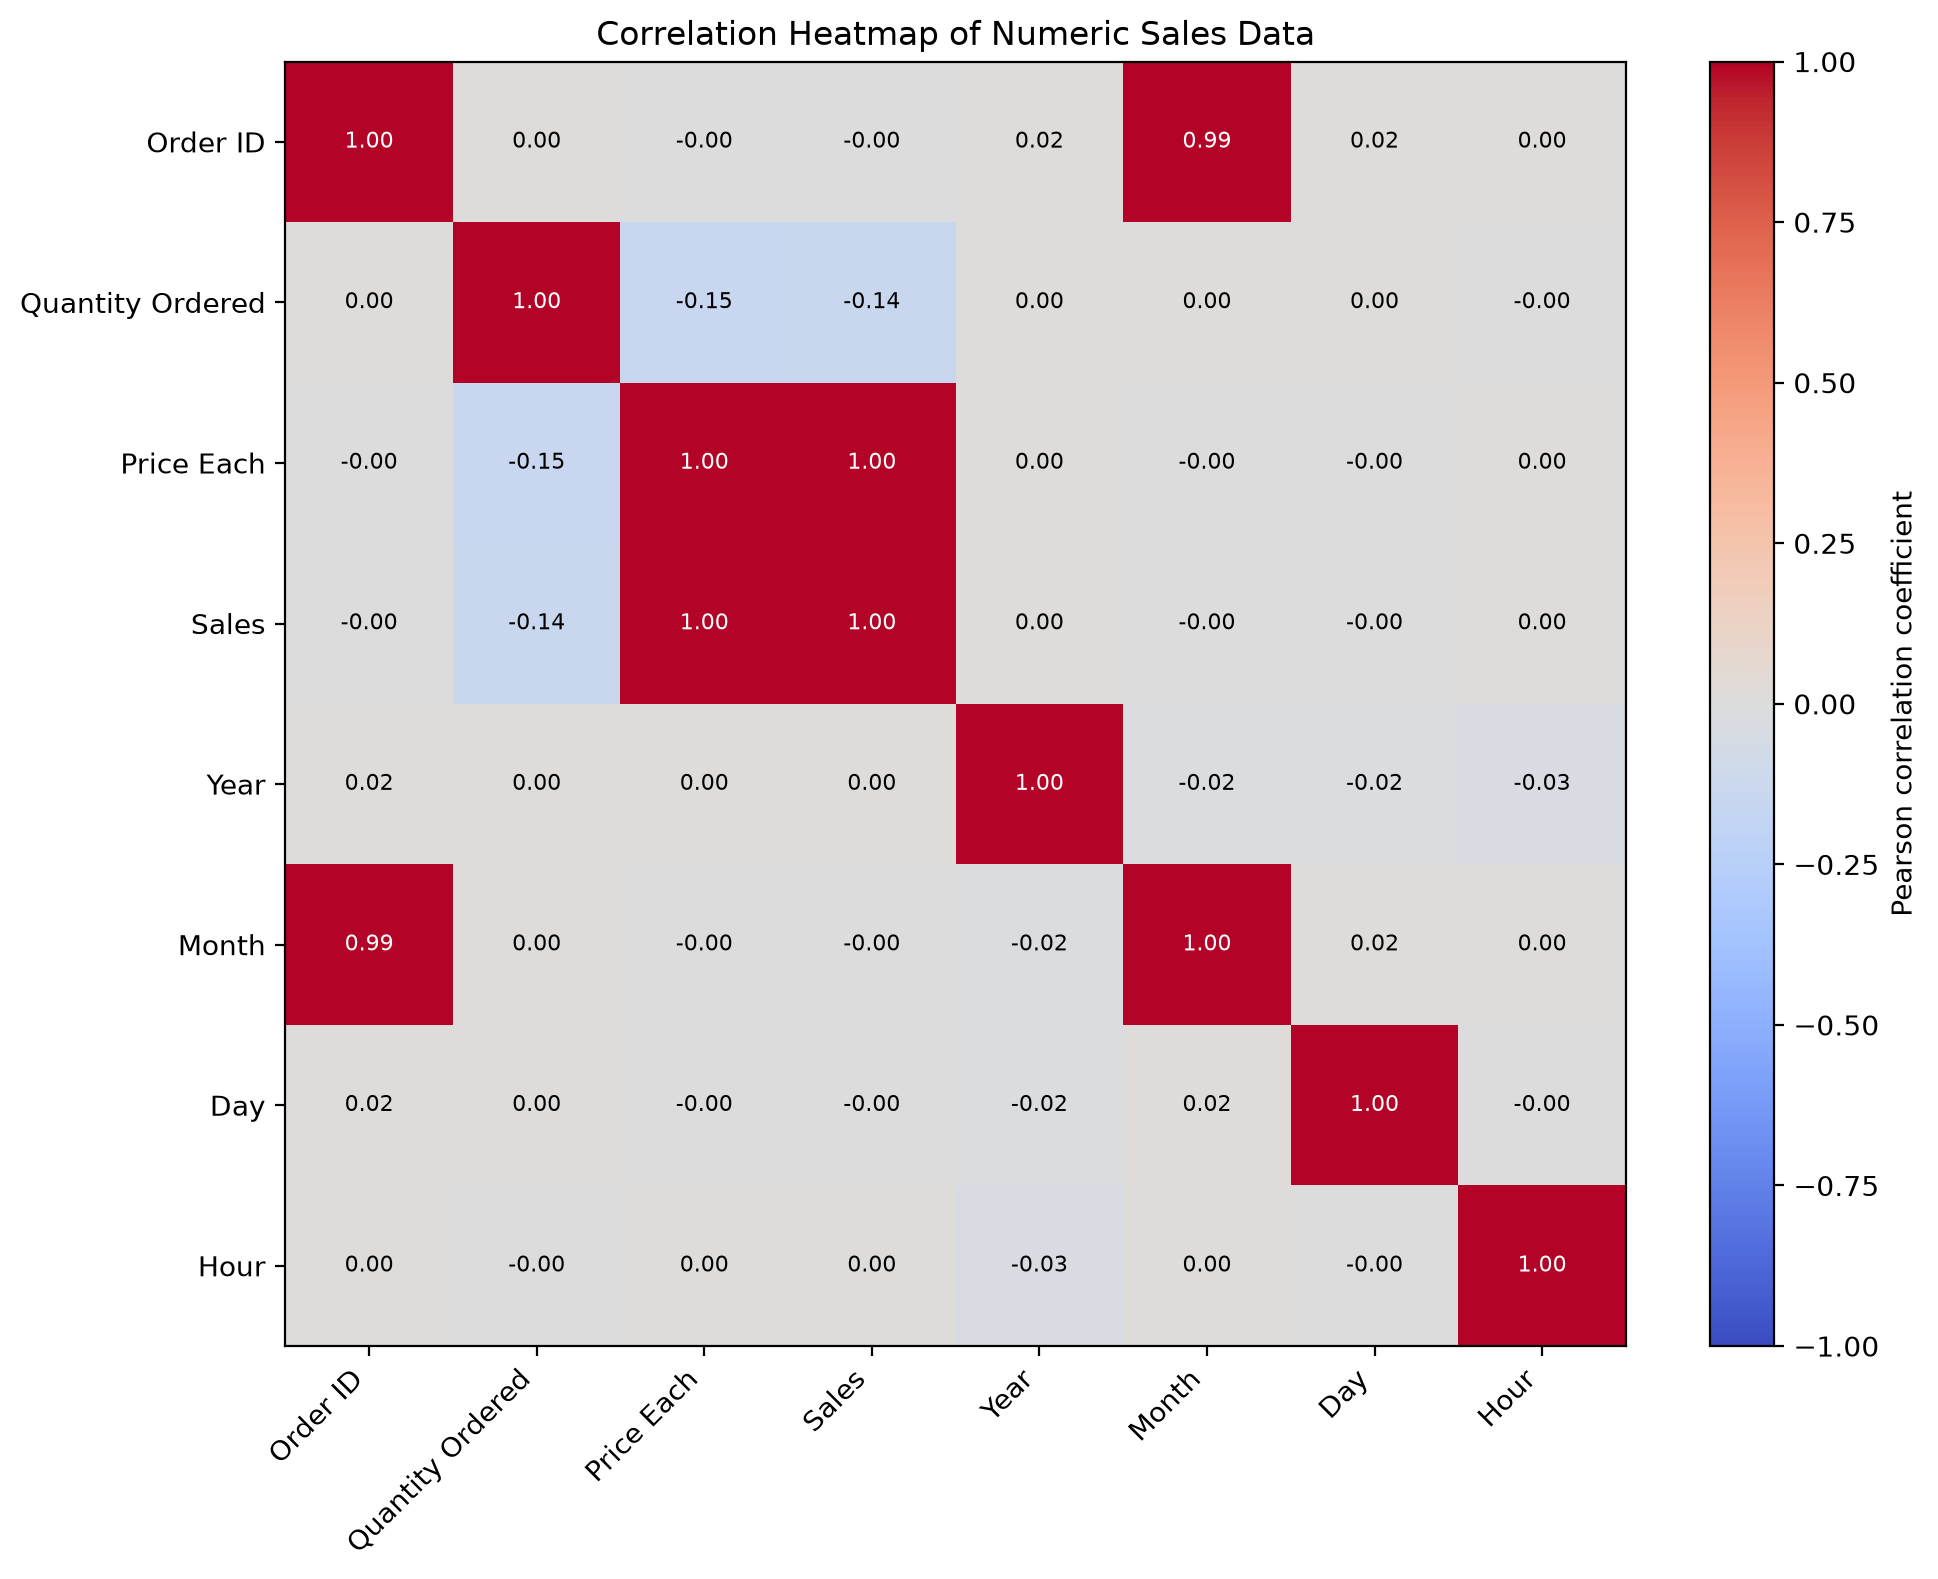


Chart: price_each_vs_sales.png


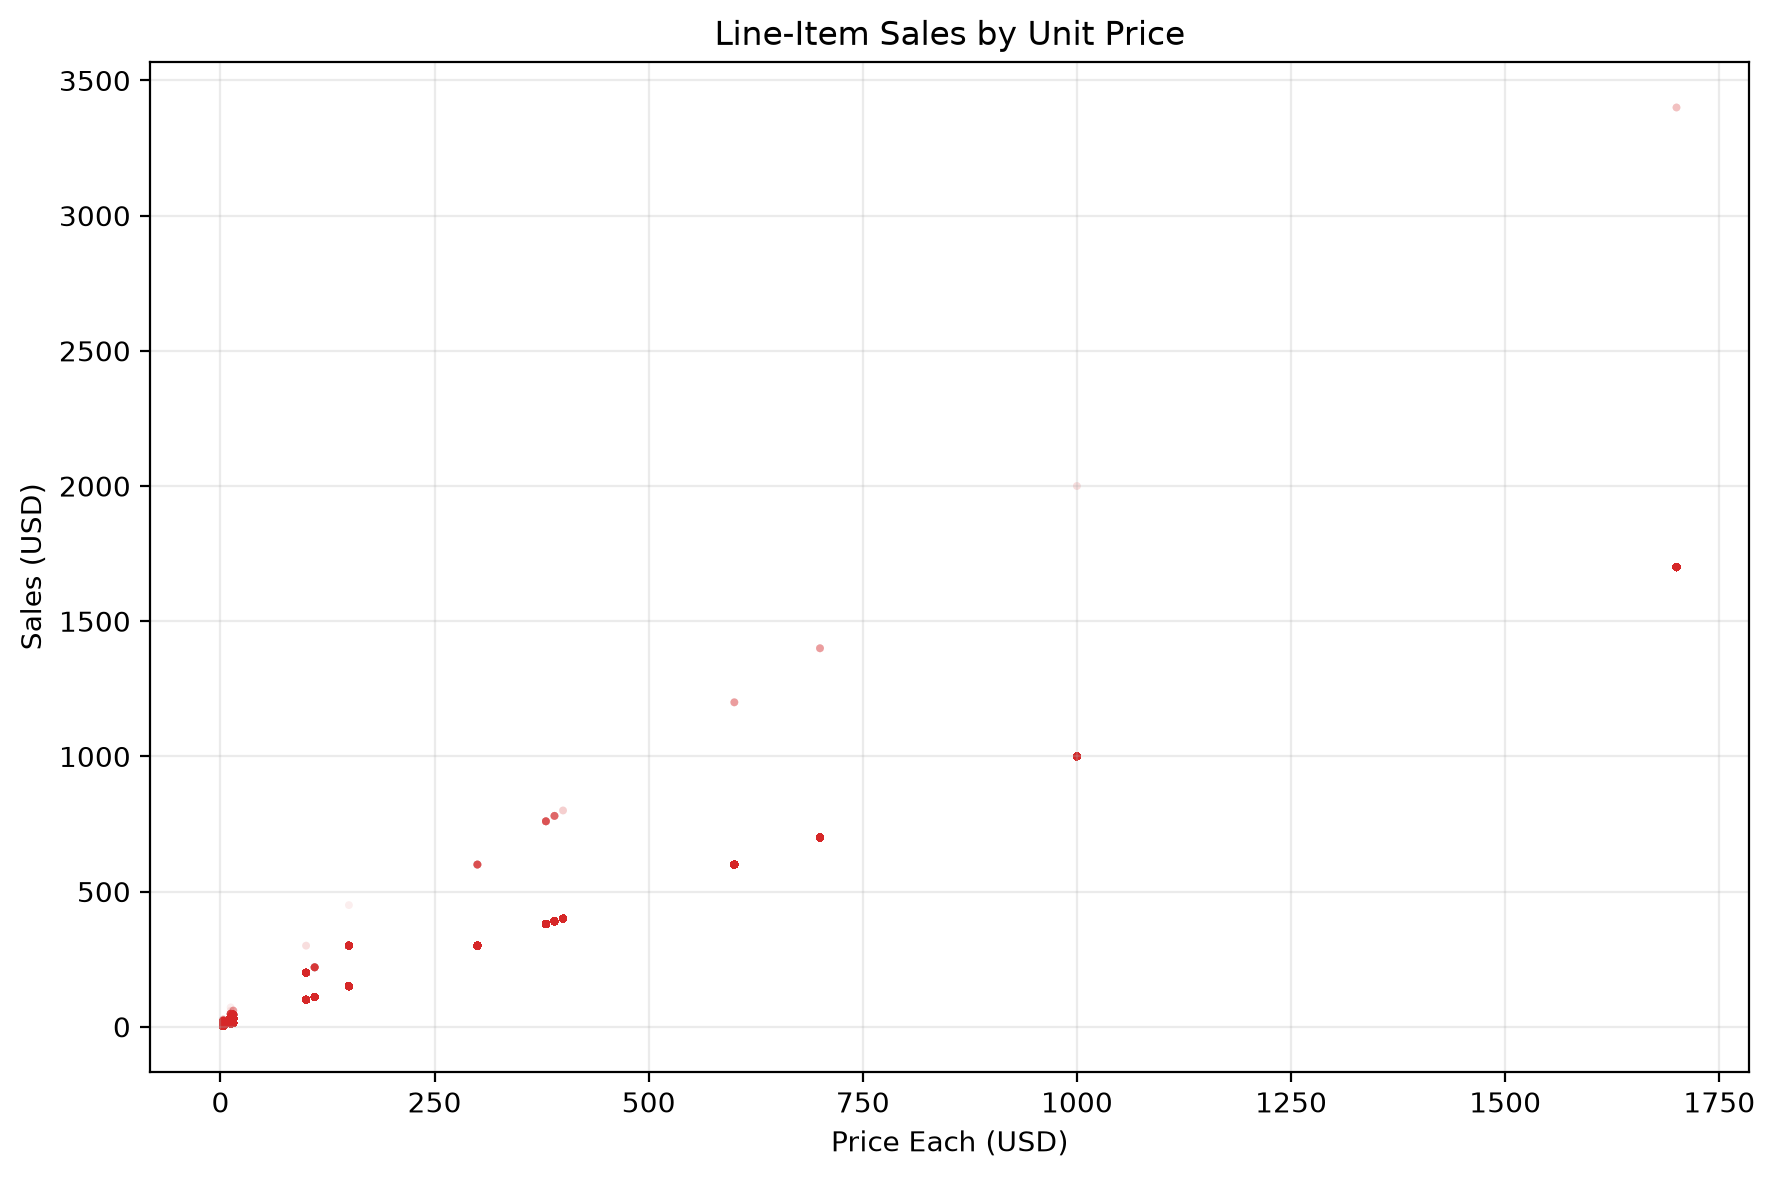


Chart: quantity_ordered_vs_sales.png


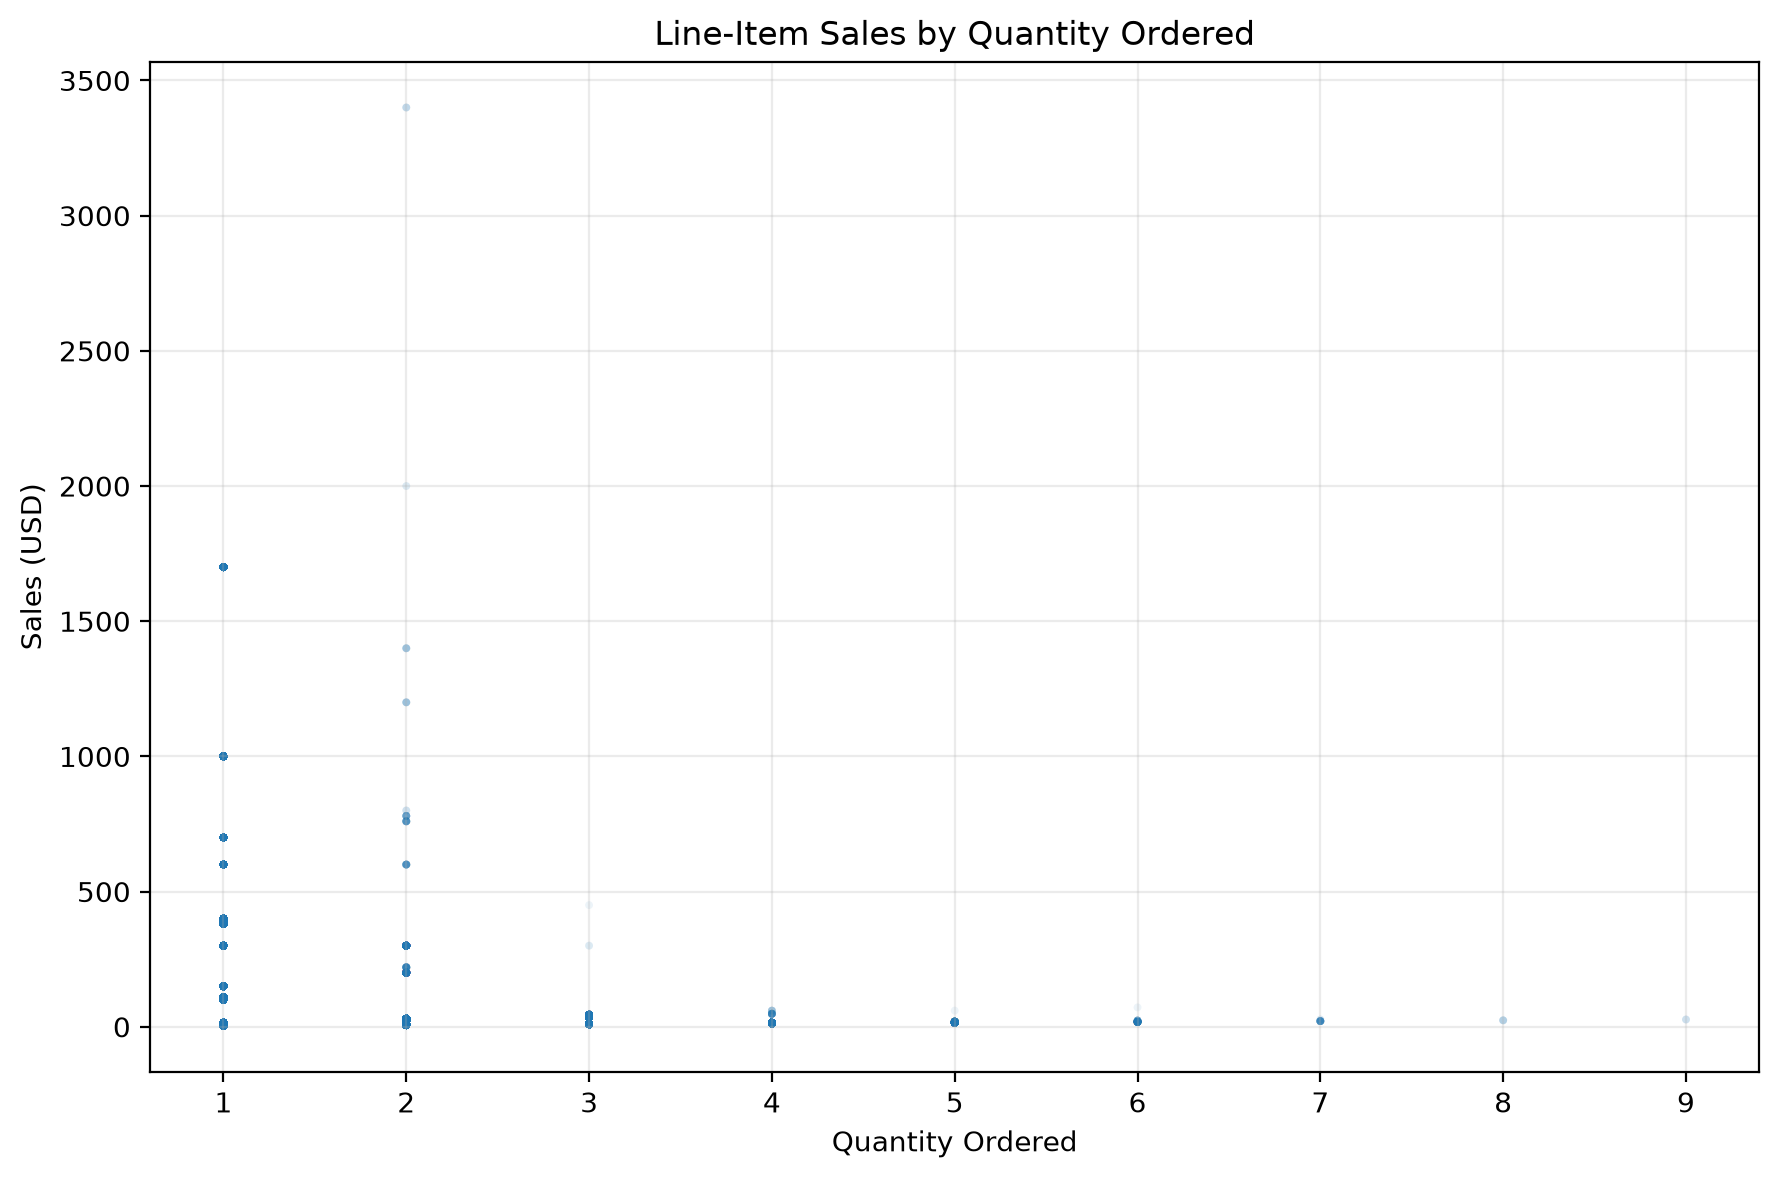


Chart: sales_vs_city.png


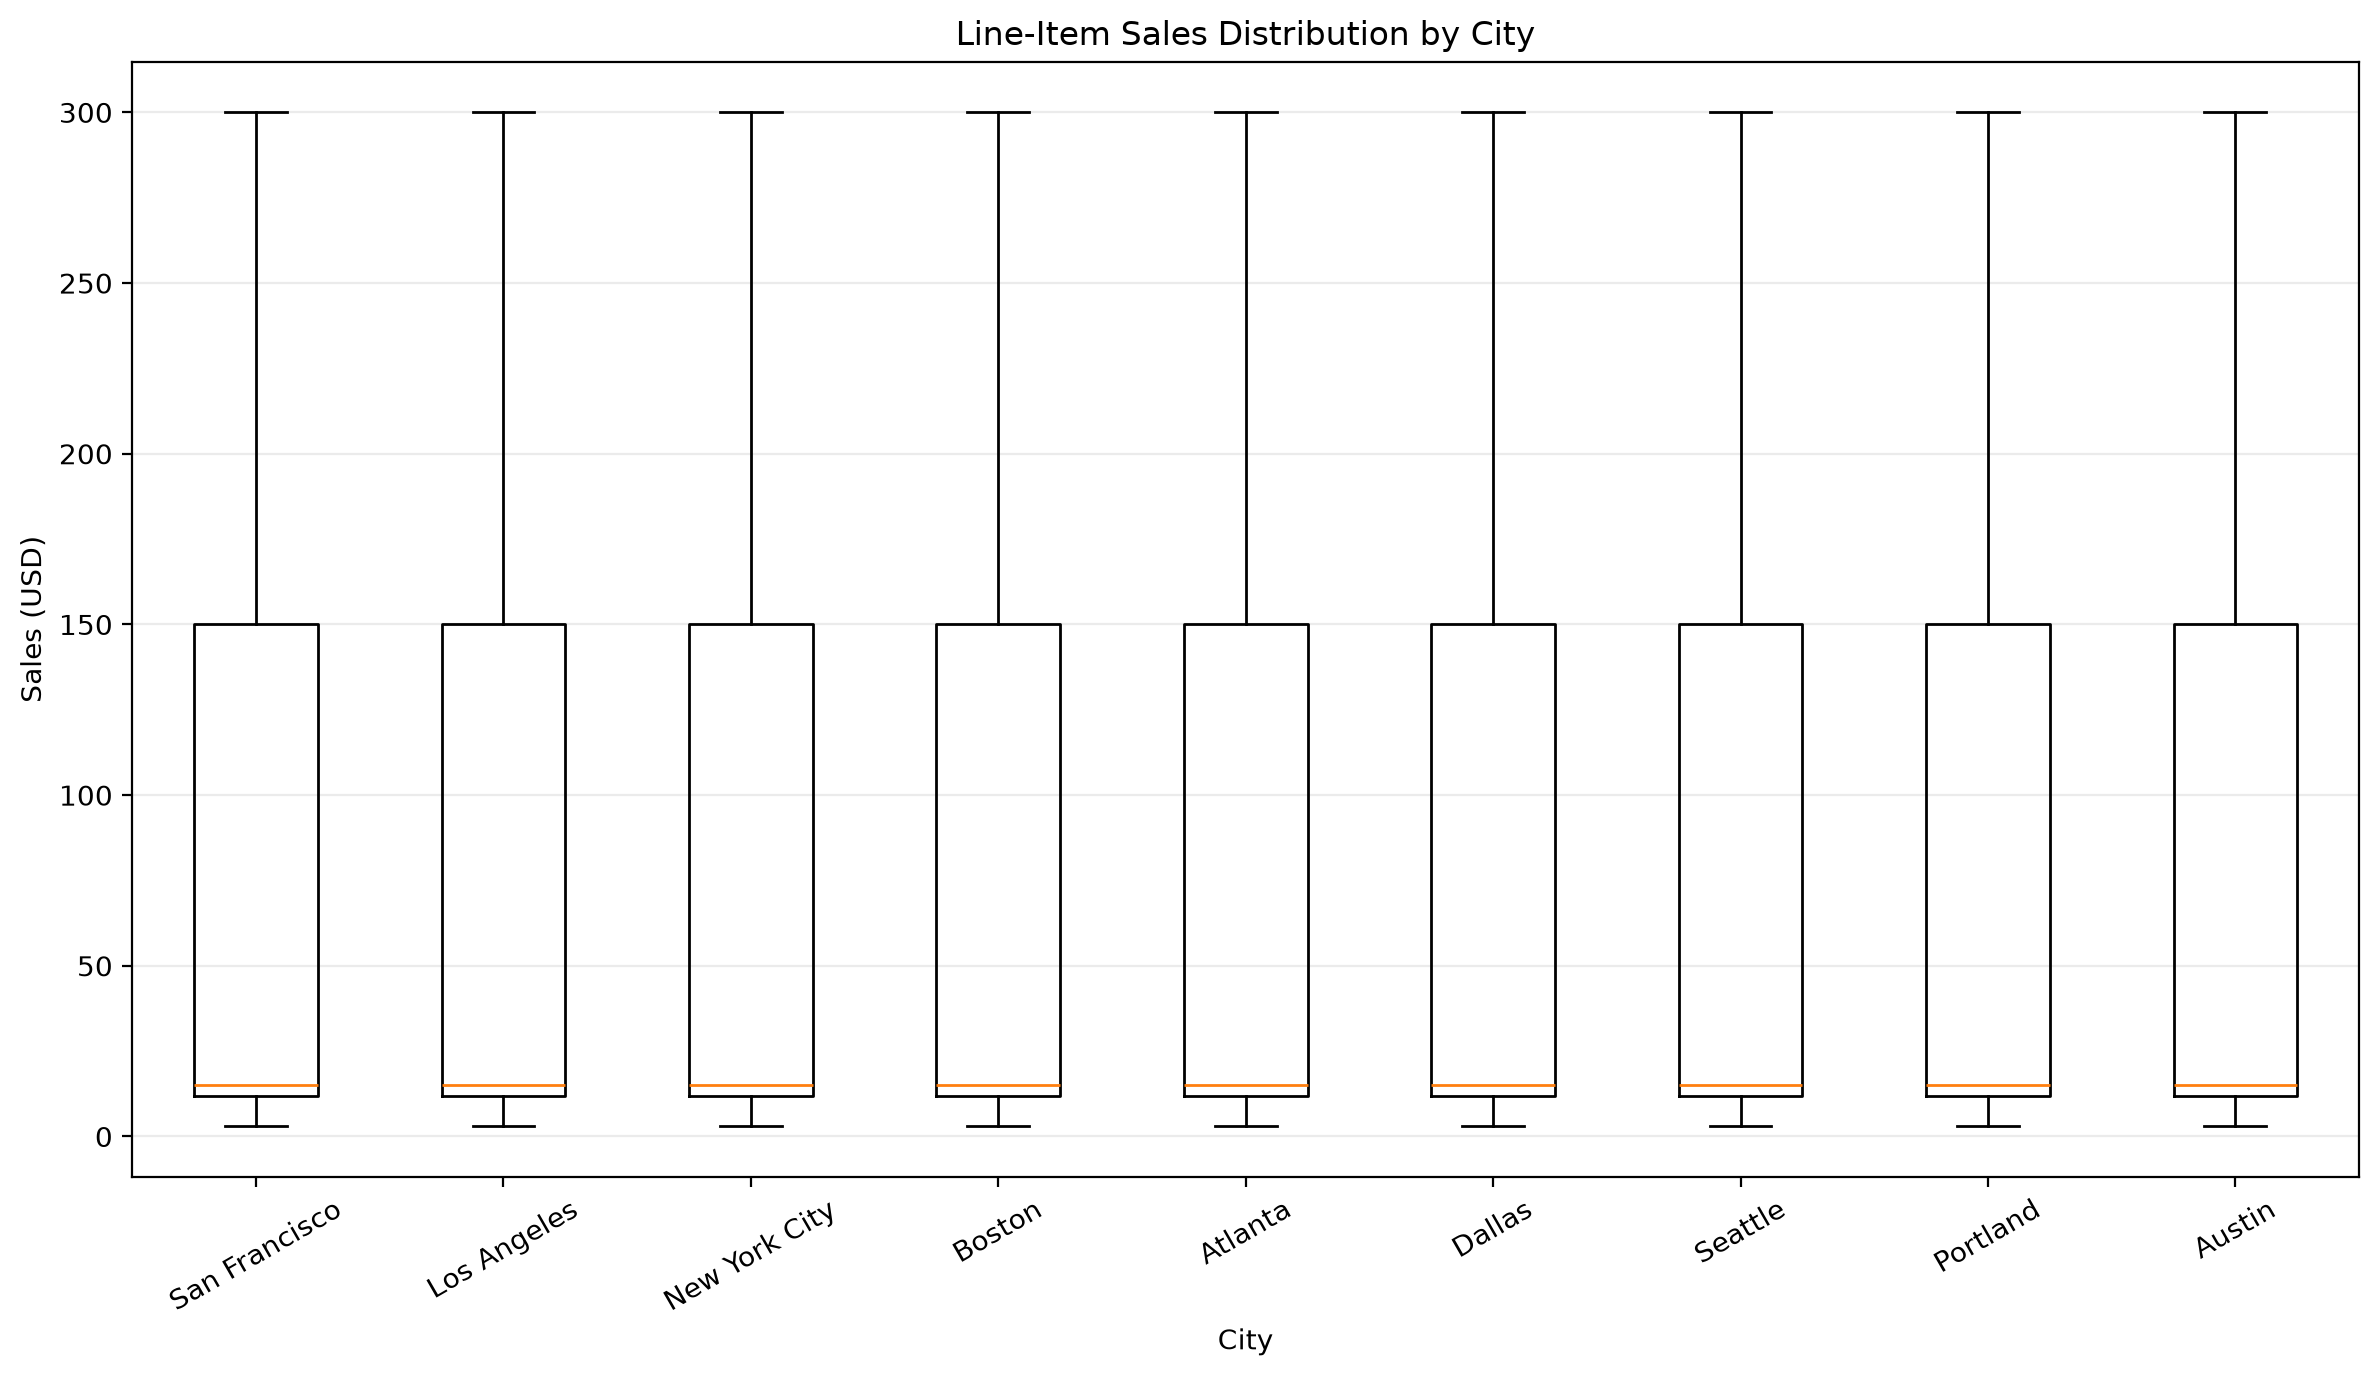


Chart: sales_vs_hour.png


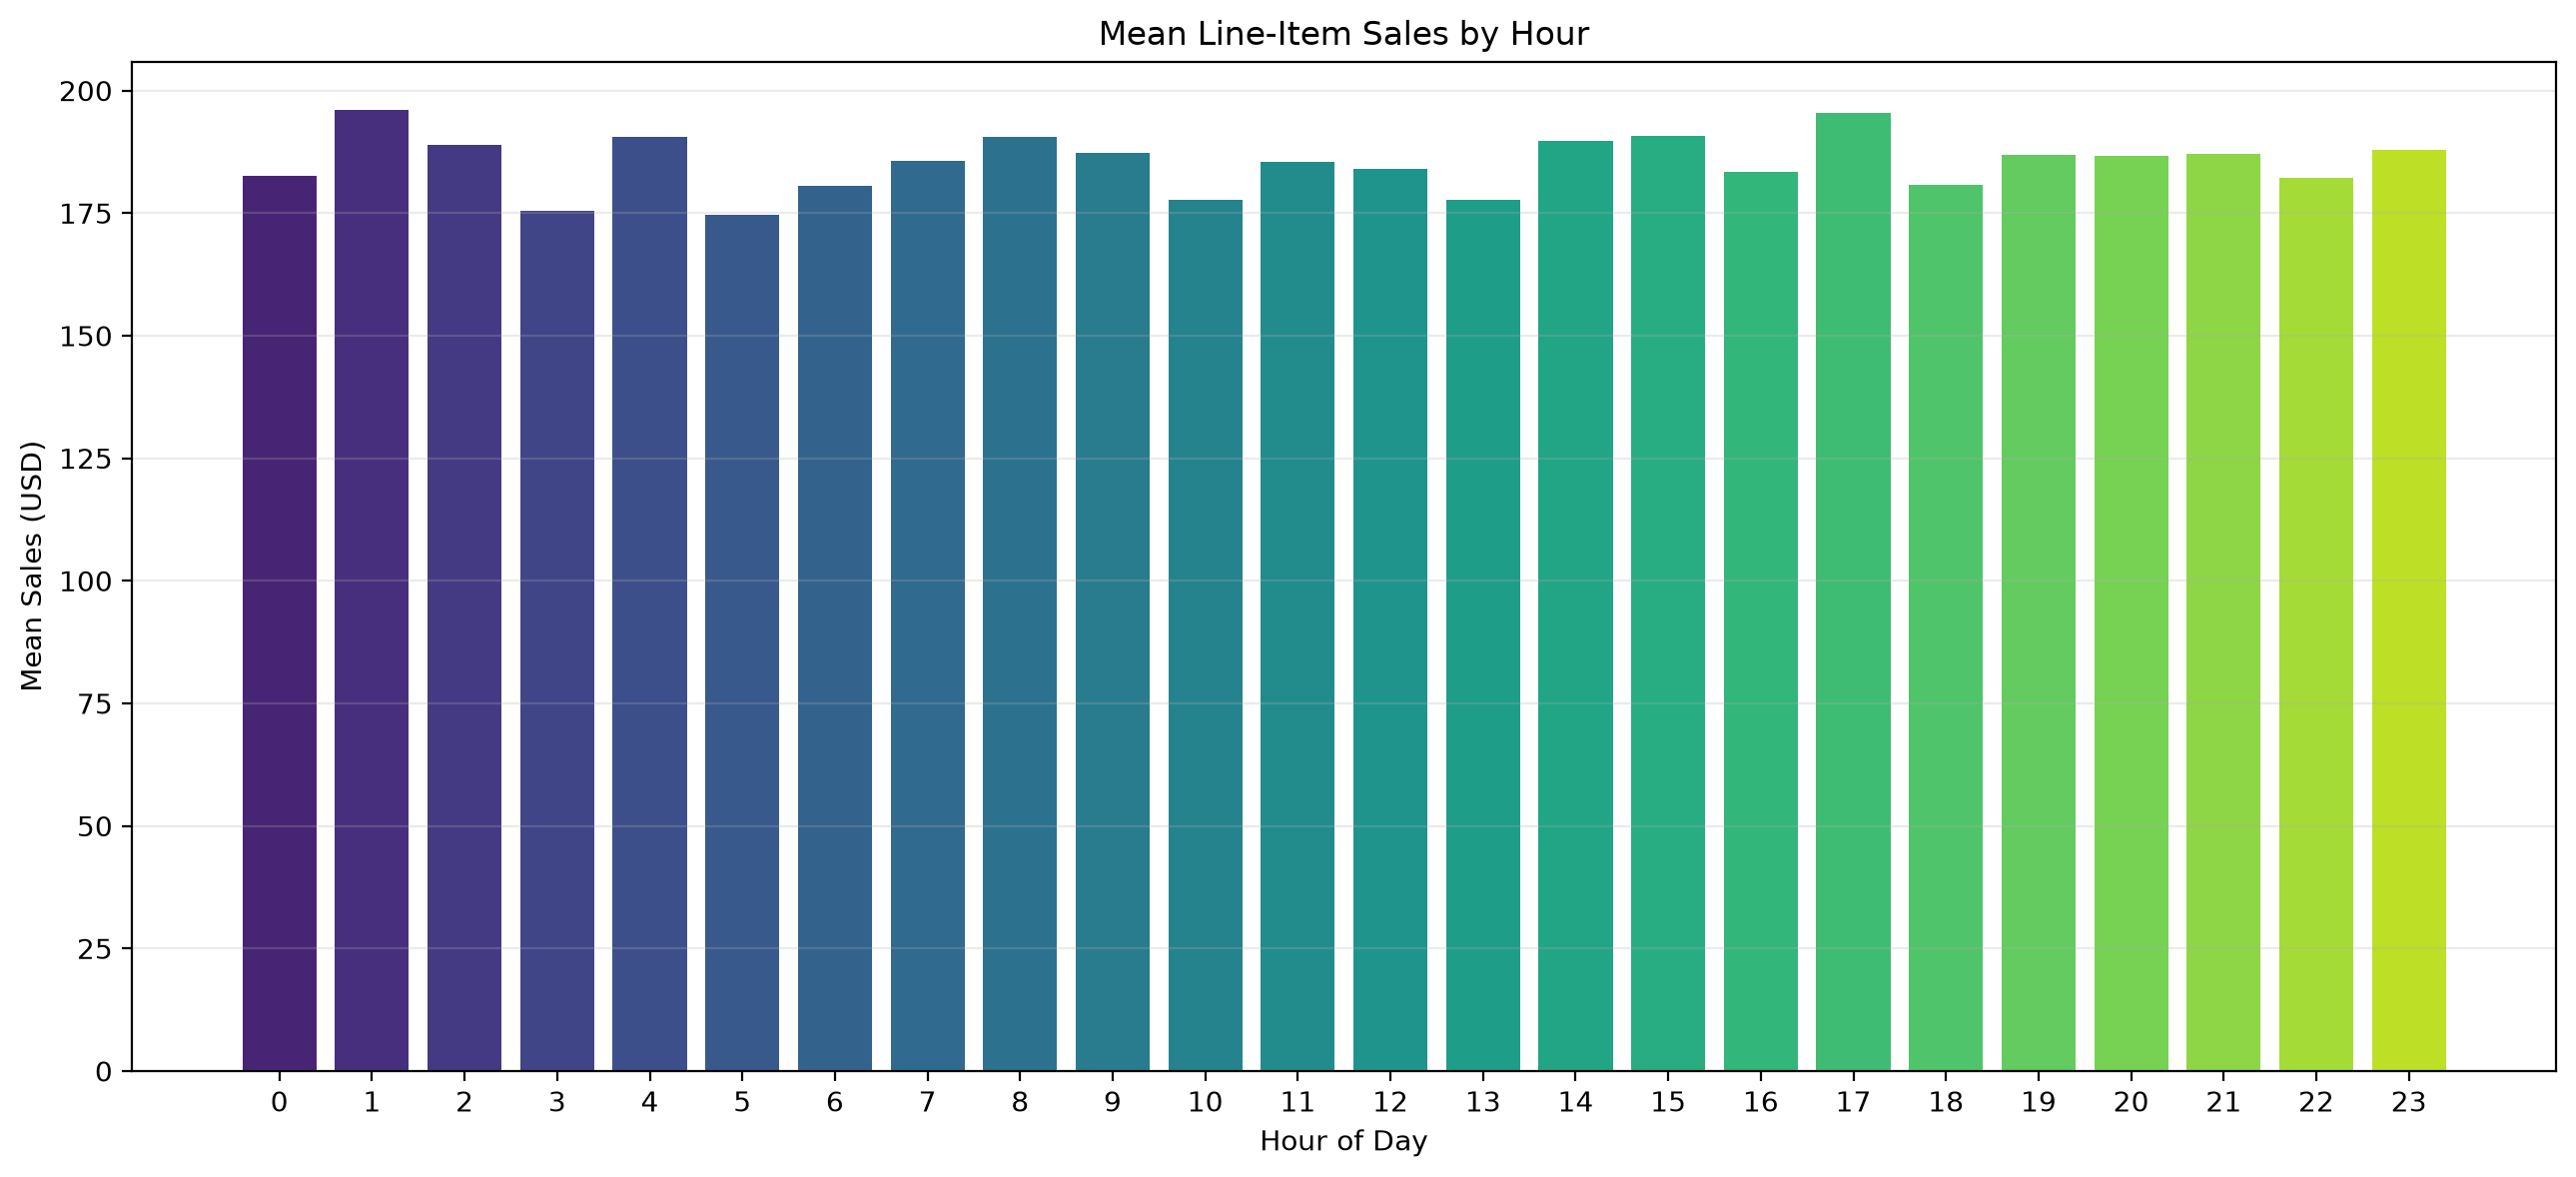


Chart: sales_vs_month.png


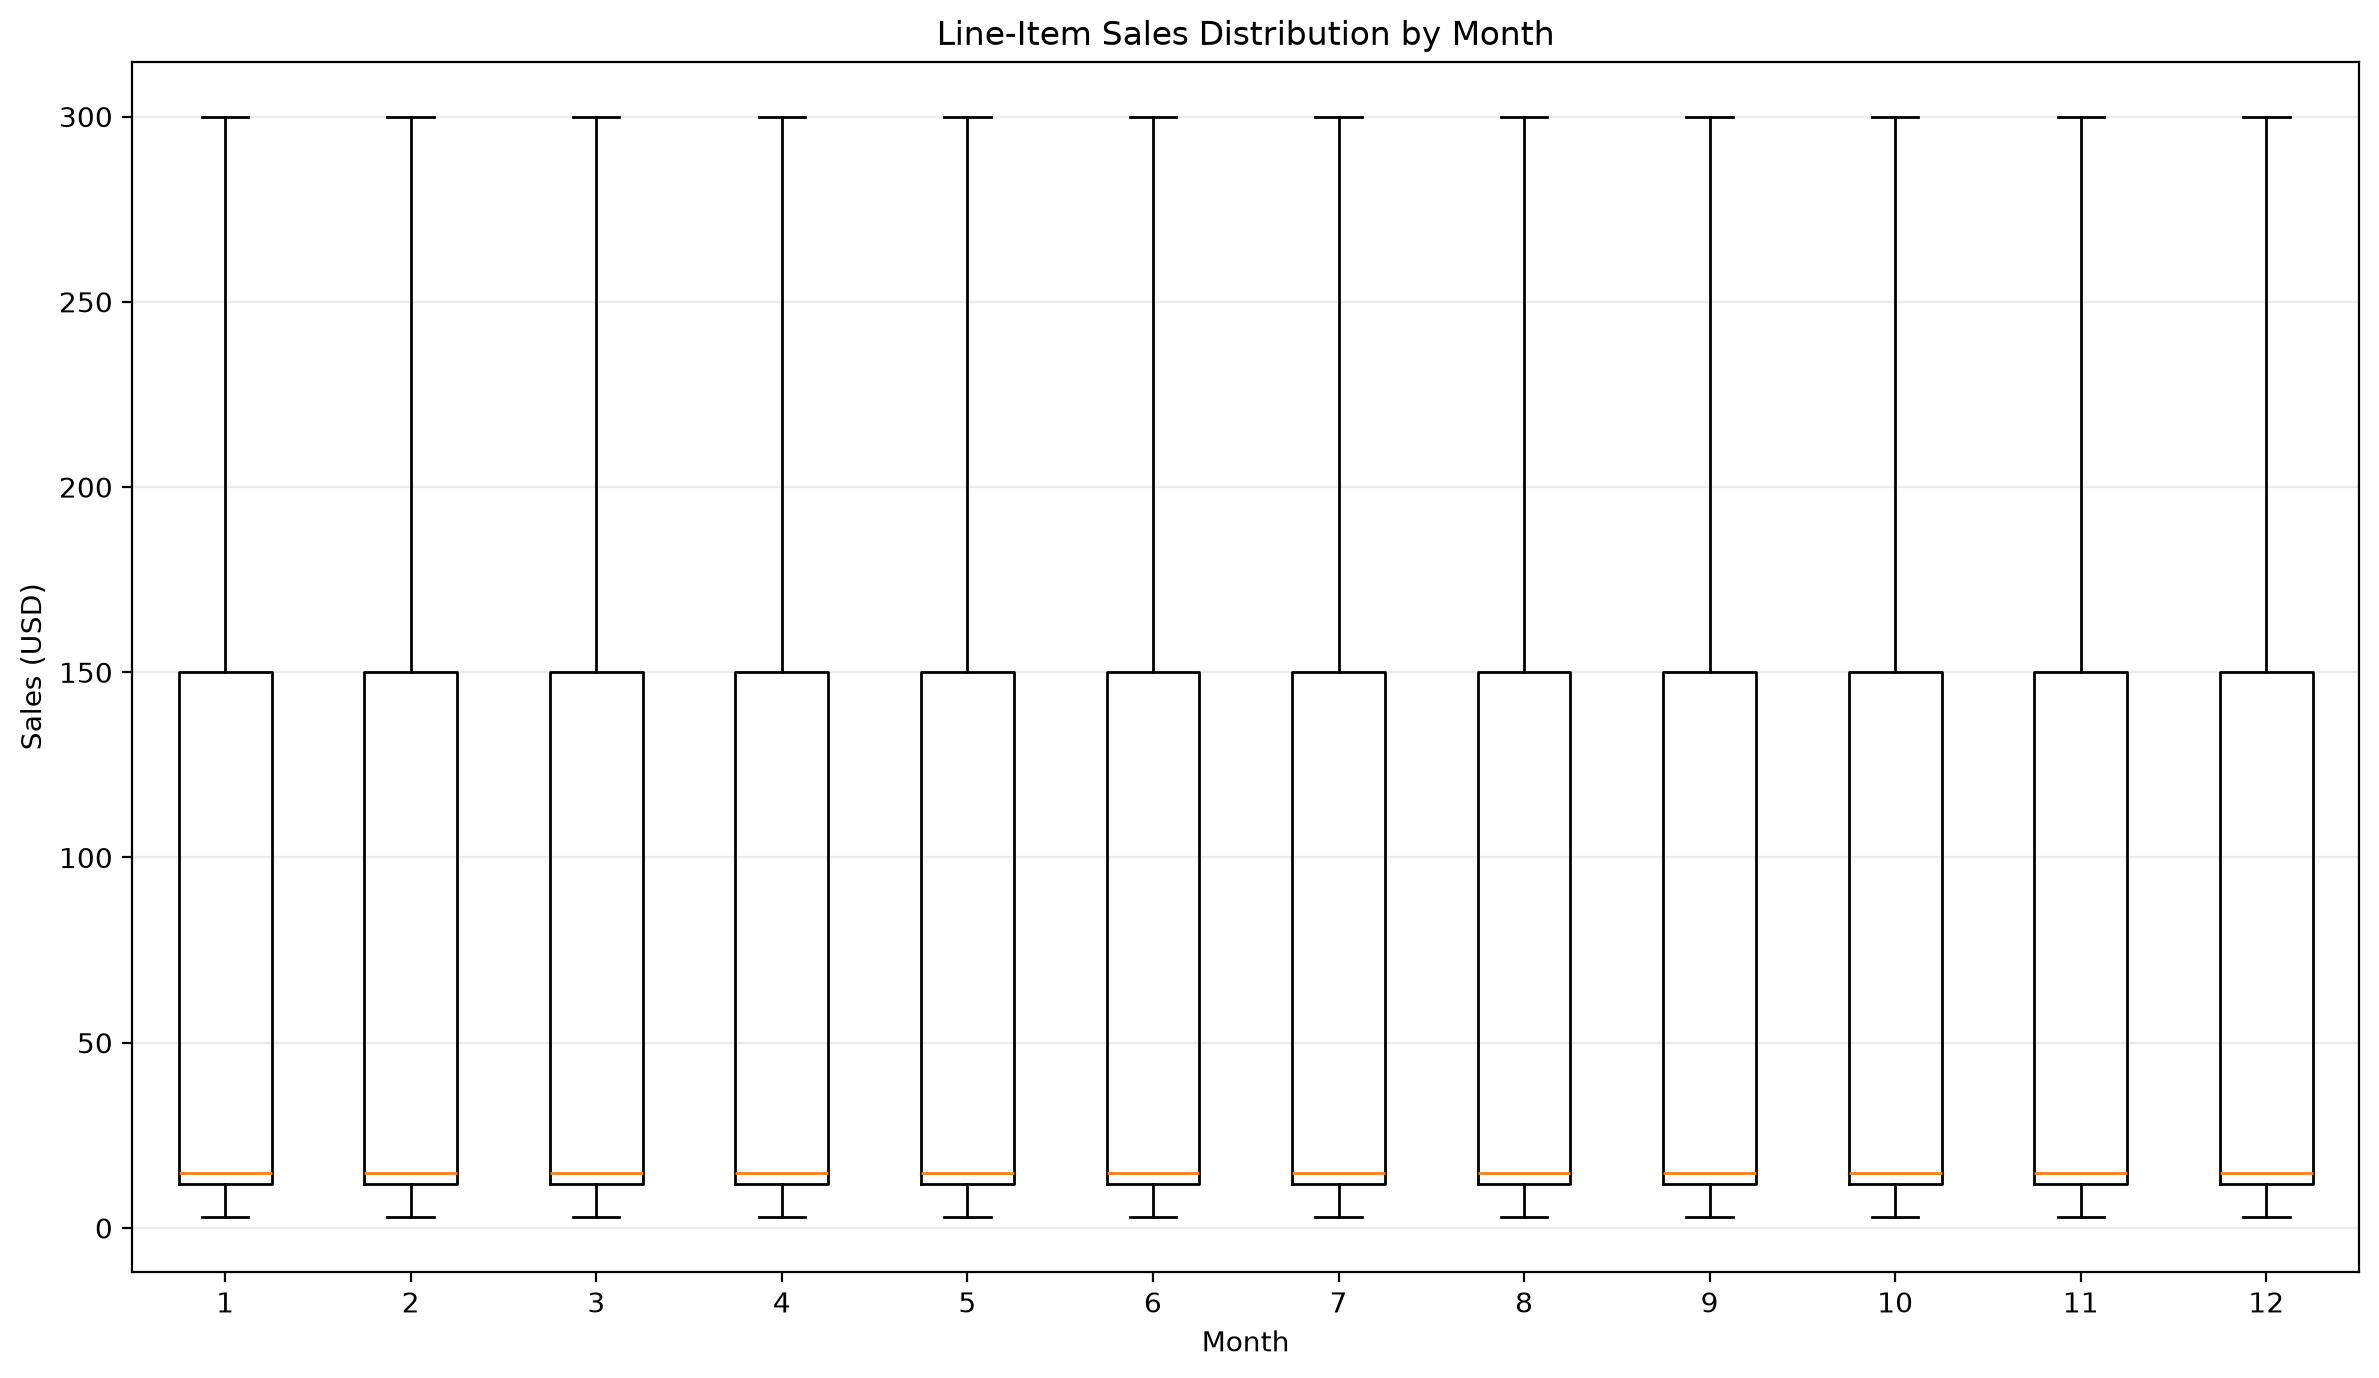


Chart: sales_vs_product.png


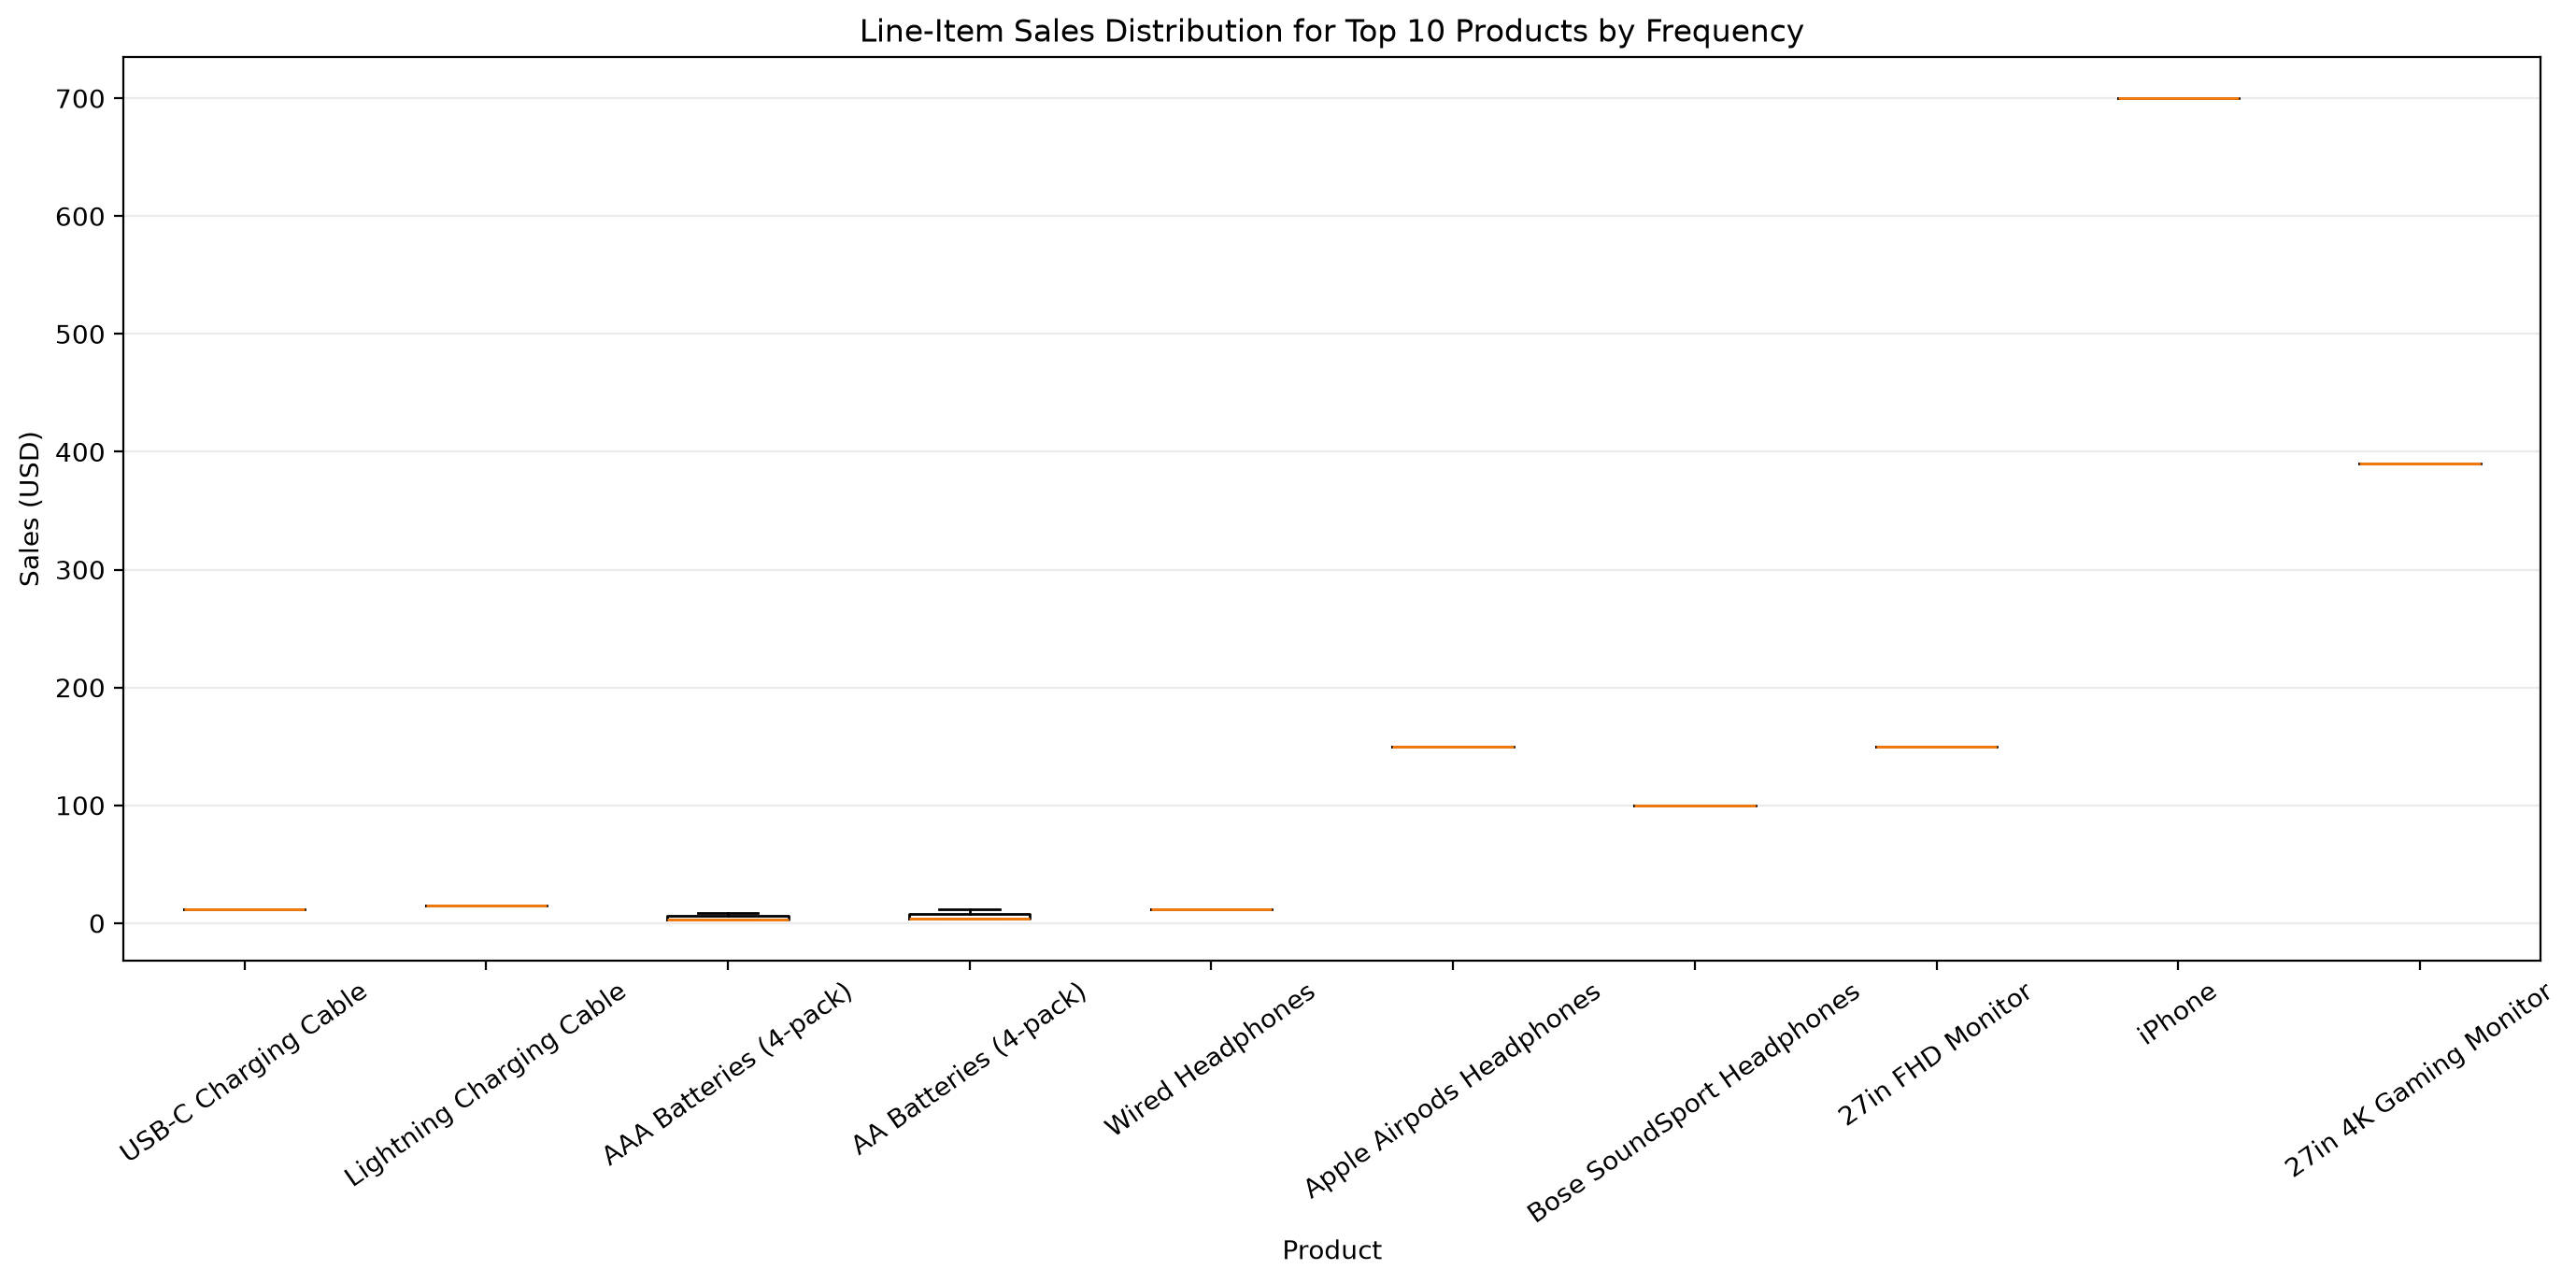


Chart: sales_vs_year.png


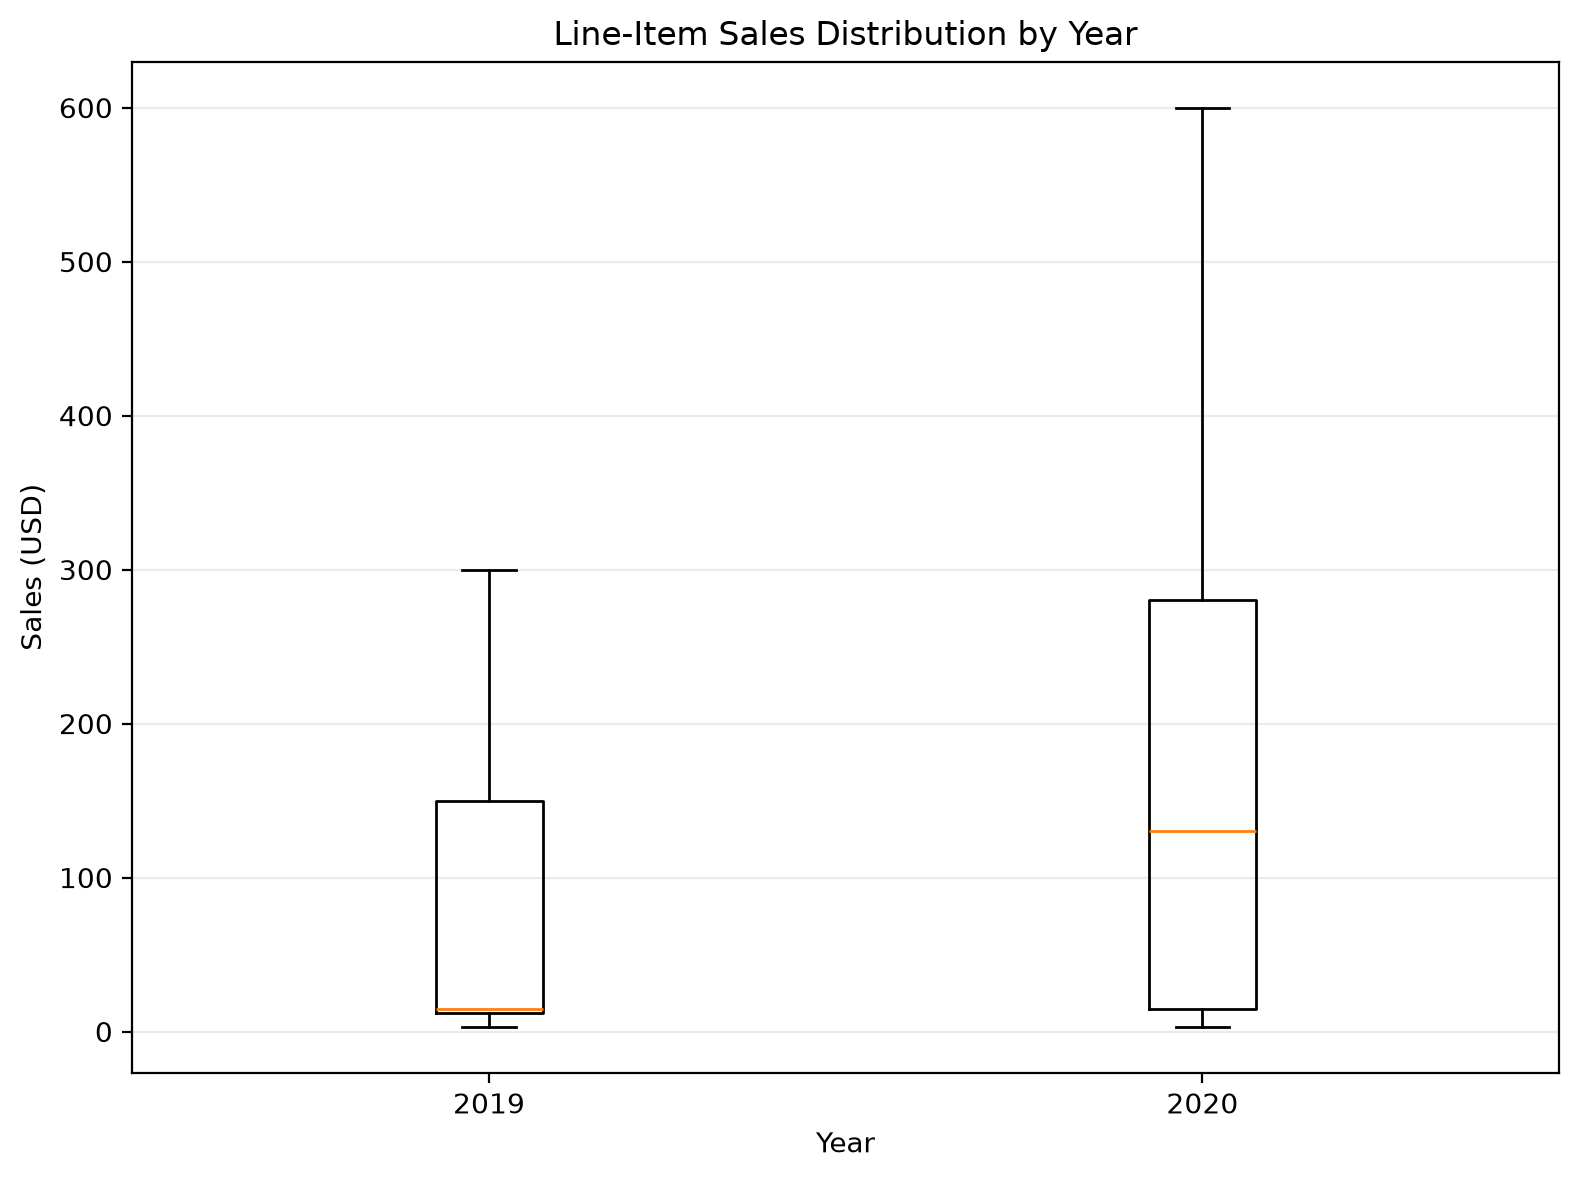

In [7]:
for chart_path in multivariate_charts:
    print(f"\nChart: {chart_path.name}")
    display(Image(filename=str(chart_path)))

## Step 5: Agent 3 — Multimodal Report Agent & Synthesis

The **Report Agent** consumes the aggregated context (`EdaContext`) and chart images as input into a vision-capable LLM model. It synthesizes executive summaries, per-chart visual findings, cross-stage insights, and consolidated assumptions. Python then deterministically assembles the final Markdown report.

In [8]:
print("Aggregating stage context into EdaContext...")
context = collect_context(
    dataset_name=raw_csv_path.stem,
    cleaned_csv_path=cleaned_csv_path,
    data_prep=prep_result,
    univariate=univariate_result,
    univariate_charts=univariate_charts,
    multivariate=multivariate_result,
    multivariate_charts=multivariate_charts,
)

print("Synthesizing and writing final report...")
report_file_path = run_report(context)
print(f"Report written to: {report_file_path}")

Aggregating stage context into EdaContext...
Synthesizing and writing final report...
Report written to: C:\Users\Sreeharsha\github-dev\agentic-ai\agentic_eda\outputs\reports\sales_data_eda_report.md


### Render Final Markdown Report

In [ ]:
report_markdown = report_file_path.read_text(encoding="utf-8")
display(Markdown(report_markdown[:3000] + "\n\n... *(report preview truncated for display)*"))